In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


1.1 Definim datasetul curat

In [ ]:
df_clean = pd.read_csv('/content/drive/MyDrive/heavy_metals/df_clean.csv')


df_clean['HM_limit_index'] = df_clean['HM_limit_index'].fillna(0)
df_clean['Rank_Category'] = df_clean['Rank_Category'].fillna(0)
df_clean.head()

,Metal,Product_category,Abbrev,Rank,Notified_by,Year,Product_type,Origin,Risk_decision,Conc,Metal_group,HM_limit_index,Rank_Category,Metal_color
0,As,feed additives,FA,1,Italy,2012,feed,Poland,undecided,62.5,G2_intermediate,3.000000,1.0,orange
1,As,feed additives,FA,1,Italy,2017,feed,United States,not serious,40.0,G2_intermediate,3.000000,1.0,orange
2,As,feed materials,FM,2,Italy,2011,feed,Austria,undecided,56.5,G2_intermediate,1.751839,2.0,orange
3,As,feed materials,FM,2,Italy,2013,feed,Austria,serious,12.4,G2_intermediate,1.751839,2.0,orange
4,As,feed materials,FM,2,Italy,2011,feed,Belgium,undecided,3.2,G2_intermediate,1.751839,2.0,orange


# 1.2. Definire coloanele

In [ ]:
feature_cols_cat = [
    'Metal',
    'Product_category',
    'Notified_by',
    'Origin',
    'Product_type',
    'Metal_group'
]

feature_cols_num = [
    'Conc',
    'HM_limit_index',
    'Rank_Category',
    'Rank',
    'Year'
]


# 1.3 Definim preprocess pipeline

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_cat),
        ('num', StandardScaler(), feature_cols_num)
    ]
)


# 🟦 PASUL 2 — SCENARIUL A: Multi-class (0,1,2)

# 2.1 Pregătirea țintei

In [ ]:
df_mc = df_clean.copy()
df_mc['y'] = df_mc['Risk_decision'].map({
    'not serious': 0,
    'serious': 1,
    'undecided': 2
})

X_mc = df_mc[feature_cols_cat + feature_cols_num]
y_mc = df_mc['y']


# 2.2 Split train/test

In [ ]:
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc, y_mc, test_size=0.30, random_state=42, stratify=y_mc
)


# 2.3 Antrenare Random Forest Multi-Class

In [ ]:
rf_mc = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)

pipe_mc = Pipeline([
    ('preprocess', preprocess),
    ('model', rf_mc)
])

pipe_mc.fit(X_train_mc, y_train_mc)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Metal', 'Product_category',
                                                   'Notified_by', 'Origin',
                                                   'Product_type',
                                                   'Metal_group']),
                                                 ('num', StandardScaler(),
                                                  ['Conc', 'HM_limit_index',
                                                   'Rank_Category', 'Rank',
                                                   'Year'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=500, random_state=42))])

# 2.4 Evaluare Multi-Class

=== MULTI-CLASS REPORT ===
              precision    recall  f1-score   support

           0       0.61      0.62      0.62       129
           1       0.93      0.94      0.94       455
           2       0.81      0.80      0.80       312

    accuracy                           0.84       896
   macro avg       0.78      0.79      0.79       896
weighted avg       0.84      0.84      0.84       896

=== MULTI-CLASS CONFUSION MATRIX ===


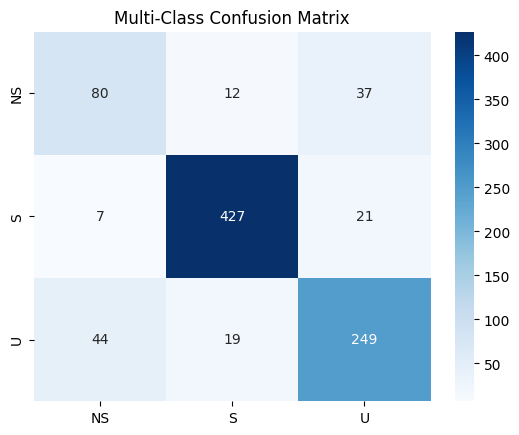

In [ ]:
y_pred_mc = pipe_mc.predict(X_test_mc)

print("=== MULTI-CLASS REPORT ===")
print(classification_report(y_test_mc, y_pred_mc))

print("=== MULTI-CLASS CONFUSION MATRIX ===")
cm_mc = confusion_matrix(y_test_mc, y_pred_mc)
sns.heatmap(cm_mc, annot=True, cmap="Blues", fmt="d",
            xticklabels=['NS','S','U'],
            yticklabels=['NS','S','U'])
plt.title("Multi-Class Confusion Matrix")
plt.show()


# 2.5 Feature importance Multi-Class

/tmp/ipython-input-337350888.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_mc.head(20), x='importance', y='feature', palette='viridis')


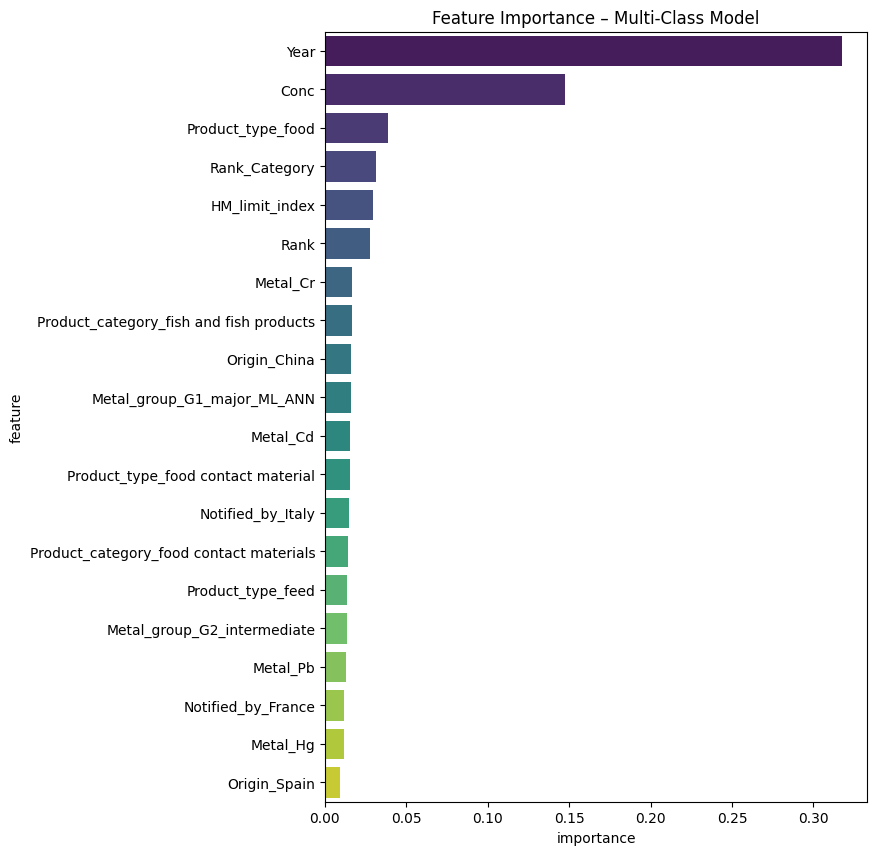

In [ ]:
ohe_mc = pipe_mc.named_steps['preprocess'].named_transformers_['cat']
cat_names_mc = ohe_mc.get_feature_names_out(feature_cols_cat)
num_names_mc = feature_cols_num

feat_names_mc = np.concatenate([cat_names_mc, num_names_mc])
feat_import_mc = pipe_mc.named_steps['model'].feature_importances_

fi_mc = pd.DataFrame({'feature': feat_names_mc, 'importance': feat_import_mc})
fi_mc = fi_mc.sort_values('importance', ascending=False)

plt.figure(figsize=(7,10))
sns.barplot(data=fi_mc.head(20), x='importance', y='feature', palette='viridis')
plt.title("Feature Importance – Multi-Class Model")
plt.show()


# 🟦 PASUL 3 — SCENARIUL B: Binary + Reclassification
3.1 Pregătire binar (eliminăm undecided din train/test)

In [ ]:
df_bin = df_clean[df_clean['Risk_decision'].isin(['serious','not serious'])].copy()

df_bin['y'] = df_bin['Risk_decision'].map({
    'not serious': 0,
    'serious': 1
})

X_bin = df_bin[feature_cols_cat + feature_cols_num]
y_bin = df_bin['y']


3.2 Train/test split

In [ ]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.30,
    random_state=42, stratify=y_bin
)


3.3 Antrenare RF binar

In [ ]:
rf_bin = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)

pipe_bin = Pipeline([
    ('preprocess', preprocess),
    ('model', rf_bin)
])

pipe_bin.fit(X_train_bin, y_train_bin)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Metal', 'Product_category',
                                                   'Notified_by', 'Origin',
                                                   'Product_type',
                                                   'Metal_group']),
                                                 ('num', StandardScaler(),
                                                  ['Conc', 'HM_limit_index',
                                                   'Rank_Category', 'Rank',
                                                   'Year'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=500, random_state=42))])

3.4 Evaluare binar

In [ ]:
y_pred_bin = pipe_bin.predict(X_test_bin)
y_prob_bin = pipe_bin.predict_proba(X_test_bin)[:,1]

print("=== BINARY REPORT ===")
print(classification_report(y_test_bin, y_pred_bin))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob_bin))


=== BINARY REPORT ===
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       129
           1       0.96      0.97      0.96       456

    accuracy                           0.95       585
   macro avg       0.92      0.92      0.92       585
weighted avg       0.95      0.95      0.95       585

ROC-AUC: 0.9736672106623148


In [ ]:
import pandas as pd
import numpy as np

# ========================================================
# 1. Extract feature names from the ColumnTransformer
# ========================================================
ct = pipe_bin.named_steps['preprocess']   # ColumnTransformer

# Numerical features
num_features = ct.transformers_[1][2]  # ['Conc','HM_limit_index','Rank_Category','Rank','Year']

# Categorical features OHE
ohe = ct.transformers_[0][1]  # OneHotEncoder
cat_features_raw = ct.transformers_[0][2]
ohe_feature_names = ohe.get_feature_names_out(cat_features_raw)

# Final list of features used in the model
all_features_bin = list(ohe_feature_names) + list(num_features)

print("Total features in binary model:", len(all_features_bin))

# ========================================================
# 2. Extract RandomForest importances
# ========================================================
rf = pipe_bin.named_steps['model']  # RandomForestClassifier
importances = rf.feature_importances_

# ========================================================
# 3. Create DataFrame
# ========================================================
fi_bin = pd.DataFrame({
    'feature': all_features_bin,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nfi_bin successfully created!")
fi_bin.head(10)


Total features in binary model: 160

fi_bin successfully created!


,feature,importance
149,Product_type_food,0.099388
155,Conc,0.074602
159,Year,0.069354
156,HM_limit_index,0.068282
158,Rank,0.067334
157,Rank_Category,0.067286
24,Product_category_fish and fish products,0.041169
4,Metal_Cr,0.035856
26,Product_category_food contact materials,0.035838
150,Product_type_food contact material,0.032125


# 3.5 Reclasificare “undecided”

In [ ]:
# 1. Selectăm undecided
df_un = df_clean[df_clean['Risk_decision'] == 'undecided'].copy()

# 2. Pregătim features pentru predict_proba
X_un = df_un[feature_cols_cat + feature_cols_num]

# 3. Generăm probabilitatea de serious
df_un['P_serious'] = pipe_bin.predict_proba(X_un)[:,1]
df_un['Predicted_bin'] = pipe_bin.predict(X_un)

# 4. Numai ACUM putem crea top 20!
top_un = df_un.sort_values('P_serious', ascending=False).head(20)


#🔥 GENERĂM GRAFIC RISC PENTRU "UNDECIDED"

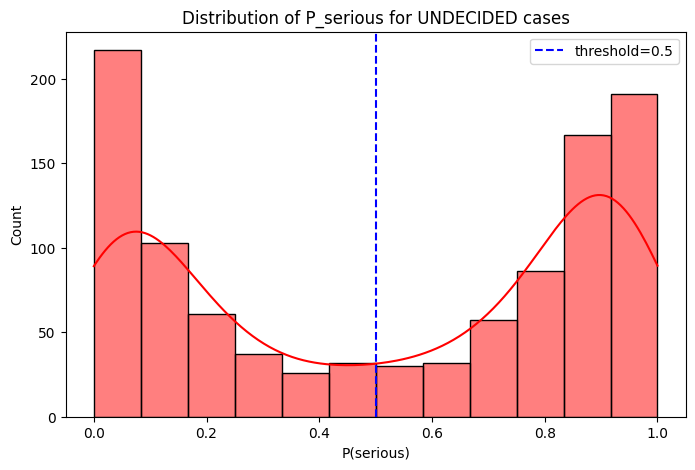

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_un['P_serious'], kde=True, color='red')
plt.axvline(0.5, color='blue', linestyle='--', label='threshold=0.5')
plt.title("Distribution of P_serious for UNDECIDED cases")
plt.xlabel("P(serious)")
plt.legend()
plt.show()


# 🔥 COMPARAȚIE SCENARIU A vs SCENARIU B (grafice + tabel)

In [ ]:
compare_df = pd.DataFrame({
    "Scenario": ["Multi-class","Binary"],
    "Accuracy":[
        (y_pred_mc==y_test_mc).mean(),
        (y_pred_bin==y_test_bin).mean()
    ],
    "F1_serious":[
        classification_report(y_test_mc, y_pred_mc, output_dict=True)['1']['f1-score'],
        classification_report(y_test_bin, y_pred_bin, output_dict=True)['1']['f1-score']
    ]
})

compare_df


,Scenario,Accuracy,F1_serious
0,Multi-class,0.843750,0.935378
1,Binary,0.945299,0.964989


In [ ]:
print(">>> df_clean columns:", df_clean.columns.tolist())
print(">>> Does Abbrev exist? ", "Abbrev" in df_clean.columns)
print(">>> Unique decisions:", df_clean['Risk_decision'].unique())

# testăm dacă NO FEATURE LIPSEȘTE
print(">>> Features exist?:")
for col in [
    'Metal', 'Product_category', 'Notified_by', 'Origin',
    'Product_type', 'Metal_group', 'Conc', 'HM_limit_index',
    'Rank_Category', 'Rank', 'Year'
]:
    print(col, " → ", col in df_clean.columns)


>>> df_clean columns: ['Metal', 'Product_category', 'Abbrev', 'Rank', 'Notified_by', 'Year', 'Product_type', 'Origin', 'Risk_decision', 'Conc', 'Metal_group', 'HM_limit_index', 'Rank_Category', 'Metal_color']
>>> Does Abbrev exist?  True
>>> Unique decisions: ['undecided' 'not serious' 'serious']
>>> Features exist?:
Metal  →  True
Product_category  →  True
Notified_by  →  True
Origin  →  True
Product_type  →  True
Metal_group  →  True
Conc  →  True
HM_limit_index  →  True
Rank_Category  →  True
Rank  →  True
Year  →  True


In [ ]:
print(">>> pipe_mc exists?", 'pipe_mc' in globals())
print(">>> pipe_bin exists?", 'pipe_bin' in globals())
print(">>> y_test_mc exists?", 'y_test_mc' in globals())
print(">>> y_pred_mc exists?", 'y_pred_mc' in globals())
print(">>> y_test_bin exists?", 'y_test_bin' in globals())
print(">>> y_pred_bin exists?", 'y_pred_bin' in globals())
print(">>> y_prob_bin exists?", 'y_prob_bin' in globals())
print(">>> fi_mc exists?", 'fi_mc' in globals())
print(">>> fi_bin exists?", 'fi_bin' in globals())


>>> pipe_mc exists? True
>>> pipe_bin exists? True
>>> y_test_mc exists? True
>>> y_pred_mc exists? True
>>> y_test_bin exists? True
>>> y_pred_bin exists? True
>>> y_prob_bin exists? True
>>> fi_mc exists? True
>>> fi_bin exists? True


In [ ]:
feature_abbrev_map = {
    'Year': 'Year',
    'Conc': 'Conc',
    'Product_type_food': 'Food',
    'Rank_Category': 'RankCat',
    'HM_limit_index': 'HM-Limit',
    'Rank': 'Rank',
    'Metal_Cr': 'Cr',
    'Metal_Cd': 'Cd',
    'Product_category_fish and fish products': 'FFP',
    'Product_category_food contact materials': 'FCM',
    'Origin_China': 'CN',
    'group_G1_major_ML_ANN': 'G1'
}

fi_mc['feature_short'] = (
    fi_mc['feature']
    .map(feature_abbrev_map)
    .fillna(fi_mc['feature'])   # fallback sigur
)


/tmp/ipython-input-3132929405.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(axE.get_xticklabels(), rotation=90)
/tmp/ipython-input-3132929405.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3132929405.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


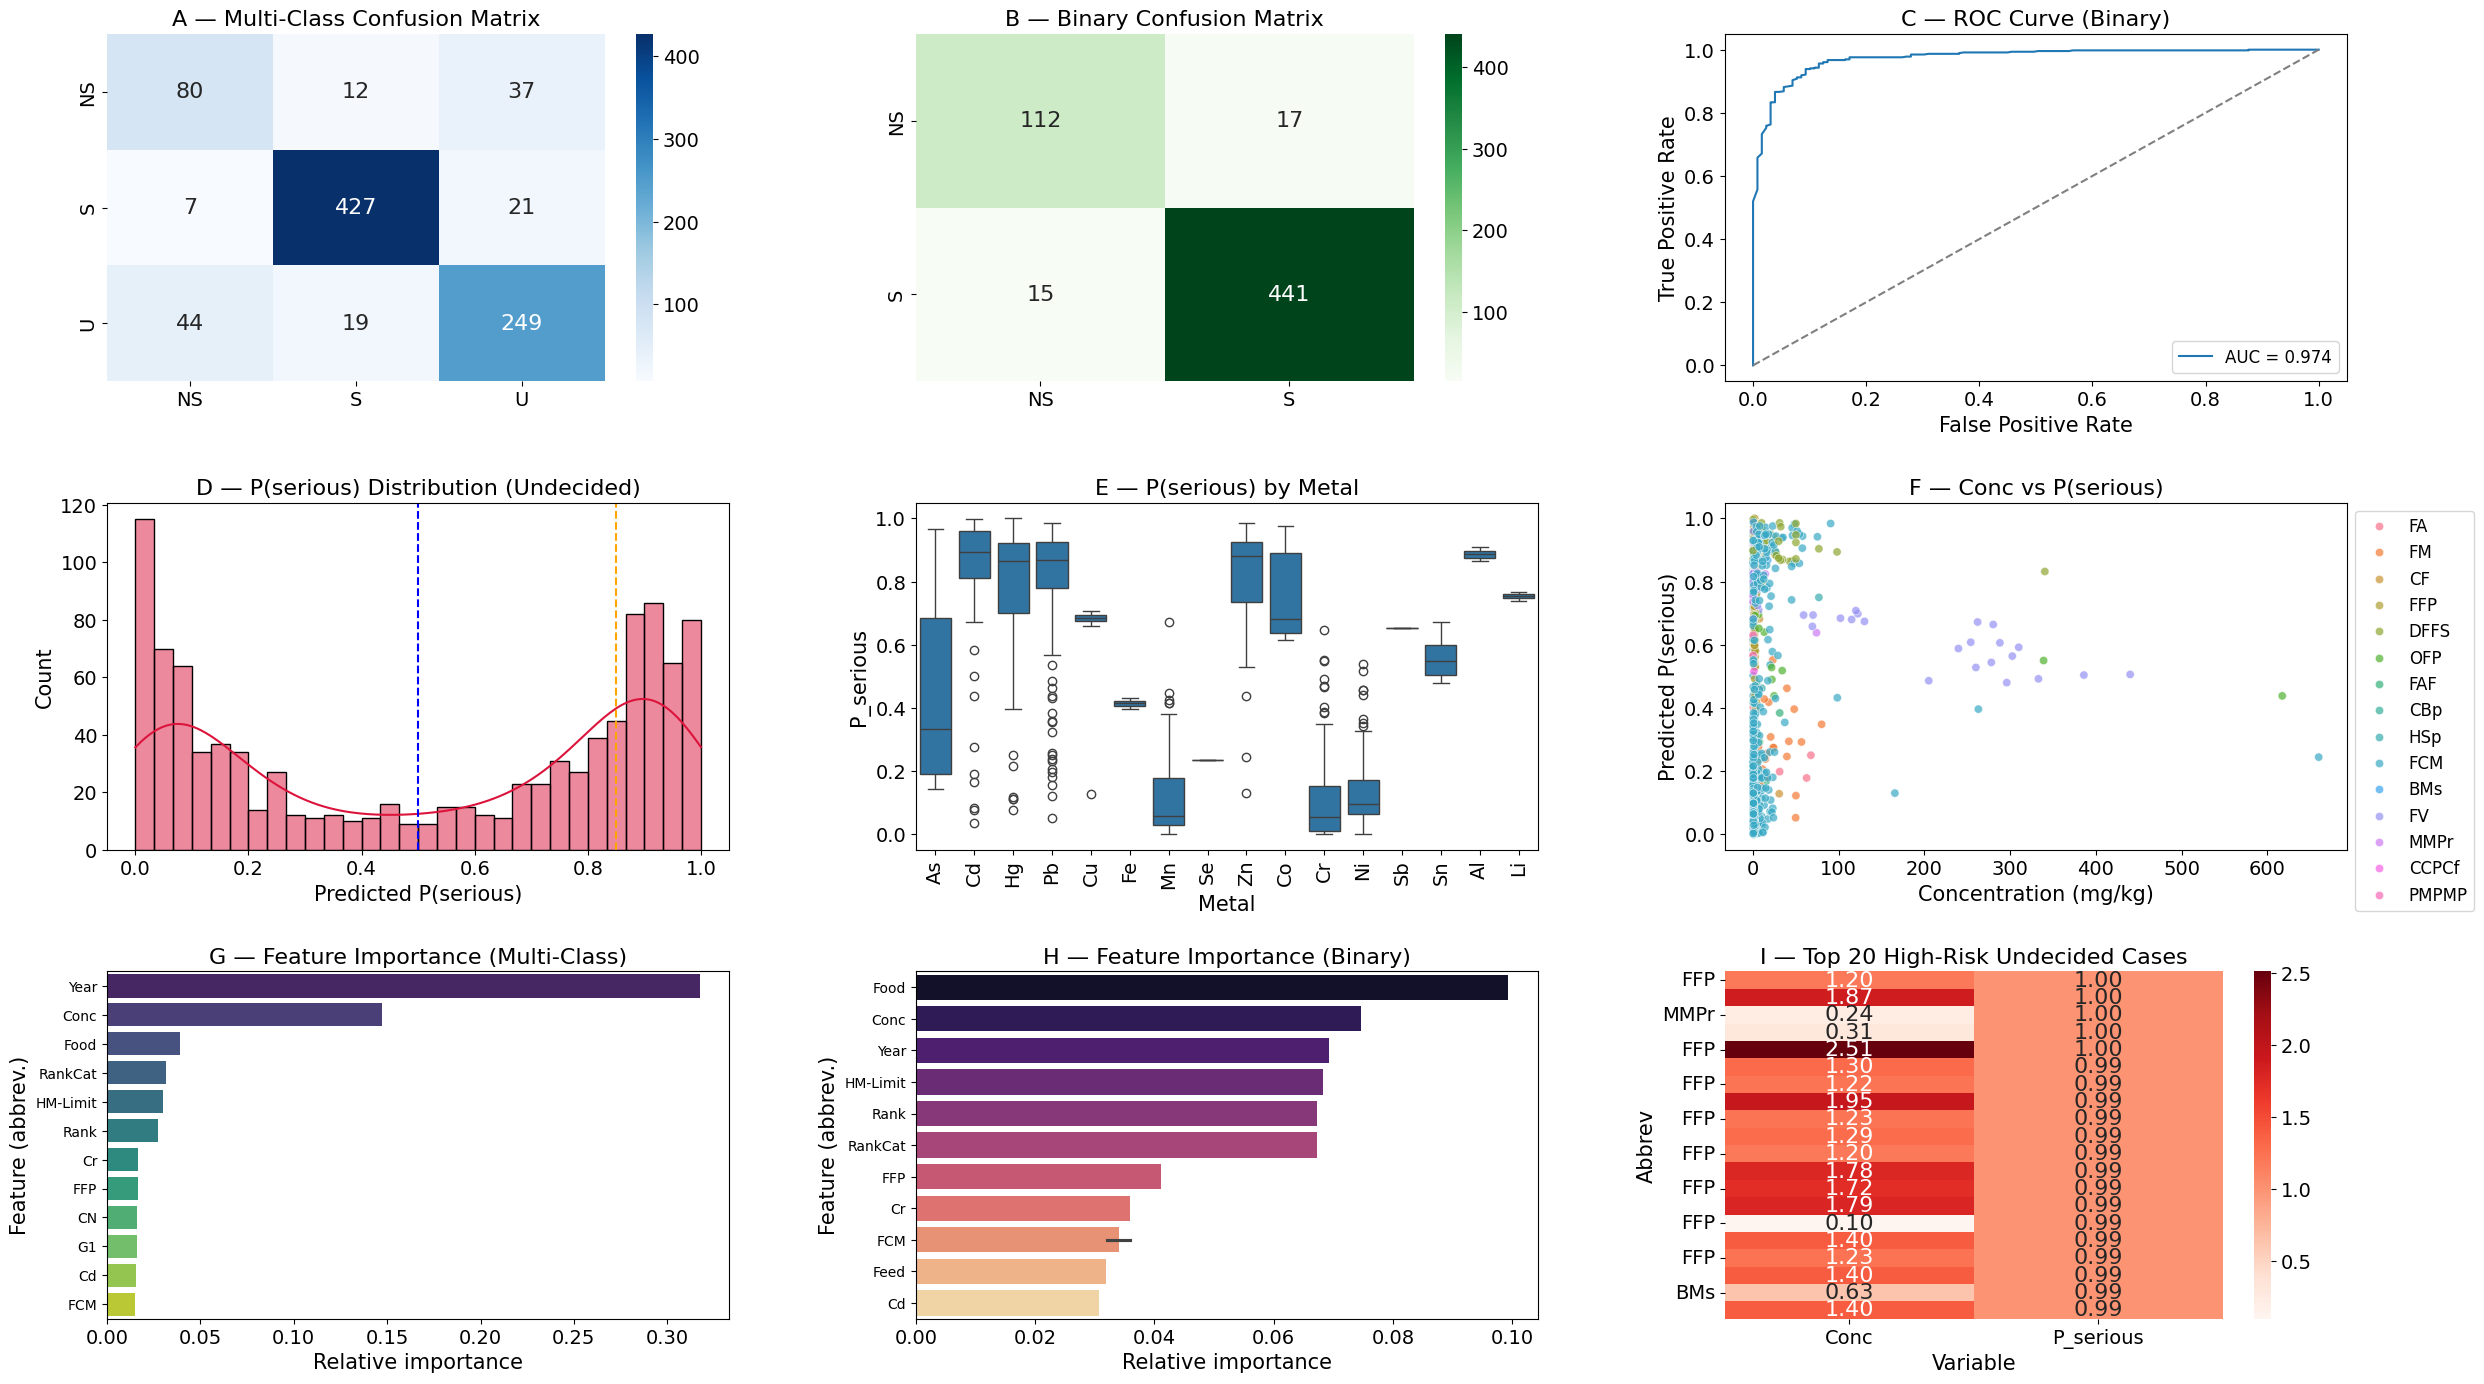

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

plt.rcParams.update({
    'font.size': 16,          # font general
    'axes.titlesize': 16,     # titluri subplot
    'axes.labelsize': 15,     # label axe
    'xtick.labelsize': 14,    # ticks X
    'ytick.labelsize': 14,    # ticks Y
    'legend.fontsize': 12
})

# ---------------------------------------------------------------
# 0. CREĂM DICTIONARUL CAT → ABBREV DIN df_clean
# ---------------------------------------------------------------
cat2abbr = (
    df_clean[['Product_category', 'Abbrev']]
    .drop_duplicates()
    .set_index('Product_category')['Abbrev']
    .to_dict()
)

# Funcție utilitară pentru scurtarea feature-urilor din OneHotEncoder
def shorten_feature_name(feat):
    if feat.startswith("Product_category_"):
        long_name = feat.replace("Product_category_", "")
        return cat2abbr.get(long_name, long_name)
    if feat.startswith("Product_type_"):
        return feat.replace("Product_type_", "")
    if feat.startswith("Notified_by_"):
        return feat.replace("Notified_by_", "")
    if feat.startswith("Origin_"):
        return feat.replace("Origin_", "")
    if feat.startswith("Metal_"):
        return feat.replace("Metal_", "")
    return feat

# ---------------------------------------------------------------
# 1. RE-CALCULĂM P_SERIOUS ȘI TOP 20 (UNDISPUTED)
# ---------------------------------------------------------------
df_un = df_clean[df_clean['Risk_decision'] == 'undecided'].copy()

X_un = df_un[feature_cols_cat + feature_cols_num]
df_un['P_serious'] = pipe_bin.predict_proba(X_un)[:,1]
df_un['Predicted_bin'] = pipe_bin.predict(X_un)

top_un = df_un.sort_values('P_serious', ascending=False).head(20)

# ---------------------------------------------------------------
# 2. Scurtăm numele feature-urilor pentru graficele G și H
# ---------------------------------------------------------------
fi_mc['feature_short'] = fi_mc['feature'].apply(shorten_feature_name)
fi_bin['feature_short'] = fi_bin['feature'].apply(shorten_feature_name)

# ---------------------------------------------------------------
# 3. CREĂM FIGURA 3×3
# ---------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(25, 14))

(axA, axB, axC,
 axD, axE, axF,
 axG, axH, axI) = axes.flatten()

# ===============================================================
# A — Multi-Class Confusion Matrix
# ===============================================================
cm_mc = confusion_matrix(y_test_mc, y_pred_mc)
sns.heatmap(cm_mc, annot=True, cmap="Blues", fmt="d",
            xticklabels=['NS','S','U'],
            yticklabels=['NS','S','U'],
            ax=axA)
axA.set_title("A — Multi-Class Confusion Matrix")

# ===============================================================
# B — Binary Confusion Matrix
# ===============================================================
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, cmap="Greens", fmt="d",
            xticklabels=['NS','S'],
            yticklabels=['NS','S'],
            ax=axB)
axB.set_title("B — Binary Confusion Matrix")

# ===============================================================
# C — ROC Curve (Binary)
# ===============================================================
fpr, tpr, _ = roc_curve(y_test_bin, y_prob_bin)
axC.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_bin, y_prob_bin):.3f}")
axC.plot([0,1],[0,1],'--',color='gray')
axC.set_title("C — ROC Curve (Binary)")
axC.set_xlabel("False Positive Rate")
axC.set_ylabel("True Positive Rate")
axC.legend()

# ===============================================================
# D — Histogram P(serious)
# ===============================================================
sns.histplot(df_un['P_serious'], kde=True, bins=30, color='crimson', ax=axD)
axD.axvline(0.50, ls='--', color='blue')
axD.axvline(0.85, ls='--', color='orange')
axD.set_title("D — P(serious) Distribution (Undecided)")
axD.set_xlabel("Predicted P(serious)")

# ===============================================================
# E — Boxplot P(serious) by Metal
# ===============================================================
sns.boxplot(data=df_un, x='Metal', y='P_serious', ax=axE)
axE.set_title("E — P(serious) by Metal")
axE.set_xticklabels(axE.get_xticklabels(), rotation=90)

# ===============================================================
# F — Scatter Conc vs P(serious), colored by ABBREV
# ===============================================================
sns.scatterplot(
    data=df_un,
    x='Conc',
    y='P_serious',
    hue='Abbrev',
    alpha=0.7,
    ax=axF
)
axF.set_title("F — Conc vs P(serious)")
axF.set_xlabel("Concentration (mg/kg)")
axF.set_ylabel("Predicted P(serious)")
axF.legend(bbox_to_anchor=(1,1))

# ===============================================================
# G — Feature Importance Multi-Class (SHORT LABELS)
# ===============================================================
feature_abbrev_map_mc = {
    # Numeric / regulatory
    'Year': 'Year',
    'Conc': 'Conc',
    'Rank': 'Rank',
    'Rank_Category': 'RankCat',
    'HM_limit_index': 'HM-Limit',

    # Product type
    'Product_type_food': 'Food',
    'Product_type_food contact material': 'FCM',
    # Product category (ATENȚIE la plural!)
    'Product_category_fish and fish products': 'FFP',


    # Metals
    'Metal_Cr': 'Cr',
    'Metal_Cd': 'Cd',

    # Groups / origin
    'Metal_group_G1_major_ML_ANN': 'G1',
    'Origin_China': 'CN'
}

fi_mc = fi_mc.copy()
fi_mc['feature_short'] = (
    fi_mc['feature']
    .map(feature_abbrev_map_mc)
    .fillna(fi_mc['feature'])   # fallback sigur
)

sns.barplot(
    data=fi_mc.sort_values('importance', ascending=False).head(12),
    x='importance',
    y='feature_short',
    palette='viridis',
    ax=axG
)

axG.set_title("G — Feature Importance (Multi-Class)")
axG.set_xlabel("Relative importance")
axG.set_ylabel("Feature (abbrev.)")
axG.tick_params(axis='y', labelsize=10)


# ===============================================================
# H — Feature Importance Binary (SHORT LABELS)
# ===============================================================
feature_abbrev_map_bin = {
    # Numeric / regulatory
    'Year': 'Year',
    'Conc': 'Conc',
    'Rank': 'Rank',
    'Rank_Category': 'RankCat',
    'HM_limit_index': 'HM-Limit',

    # Product type
    'Product_type_food': 'Food',
    'Product_type_feed': 'Feed',
    'Product_type_food contact material': 'FCM',

    # Product category (plural!)
    'Product_category_fish and fish products': 'FFP',
    'Product_category_food contact materials': 'FCM',

    # Metals
    'Metal_Cr': 'Cr',
    'Metal_Cd': 'Cd',

    # Groups / origin
    'Metal_group_G1_major_ML_ANN': 'G1',
    'Origin_China': 'CN'
}

fi_bin = fi_bin.copy()
fi_bin['feature_short'] = (
    fi_bin['feature']
    .map(feature_abbrev_map_bin)
    .fillna(fi_bin['feature'])   # fallback sigur
)

sns.barplot(
    data=fi_bin.sort_values('importance', ascending=False).head(12),
    x='importance',
    y='feature_short',
    palette='magma',
    ax=axH
)

axH.set_title("H — Feature Importance (Binary)")
axH.set_xlabel("Relative importance")
axH.set_ylabel("Feature (abbrev.)")
axH.tick_params(axis='y', labelsize=10)

# ===============================================================
# I — Heatmap Top 20 Undecided (INDEX = ABBREV)
# ===============================================================
sns.heatmap(
    top_un[['Conc','P_serious']].set_index(top_un['Abbrev']),
    annot=True,
    cmap="Reds",
    fmt=".2f",
    ax=axI
)
axI.set_title("I — Top 20 High-Risk Undecided Cases")
axI.set_xlabel("Variable")
axI.set_ylabel("Abbrev")

# ---------------------------------------------------------------
# Format final
# ---------------------------------------------------------------
plt.tight_layout(pad=0.8)
plt.subplots_adjust(wspace=0.30, hspace=0.35)
plt.show()

fig.savefig("/content/drive/MyDrive/heavy_metals/figure1_300dpi.tiff",
            dpi=300, format='tiff')


#🔥 1. Selectăm cele patru metale de interes

In [ ]:
import pandas as pd

metale_toxice = ["Pb", "Cd", "Hg", "As"]

df_met4 = df_clean[df_clean["Metal"].isin(metale_toxice)].copy()
df_met4.head()


,Metal,Product_category,Abbrev,Rank,Notified_by,Year,Product_type,Origin,Risk_decision,Conc,Metal_group,HM_limit_index,Rank_Category,Metal_color
0,As,feed additives,FA,1,Italy,2012,feed,Poland,undecided,62.5,G2_intermediate,3.000000,1.0,orange
1,As,feed additives,FA,1,Italy,2017,feed,United States,not serious,40.0,G2_intermediate,3.000000,1.0,orange
2,As,feed materials,FM,2,Italy,2011,feed,Austria,undecided,56.5,G2_intermediate,1.751839,2.0,orange
3,As,feed materials,FM,2,Italy,2013,feed,Austria,serious,12.4,G2_intermediate,1.751839,2.0,orange
4,As,feed materials,FM,2,Italy,2011,feed,Belgium,undecided,3.2,G2_intermediate,1.751839,2.0,orange


#🔥 2. Număr notificări pentru fiecare metal

In [ ]:
notificari_metal = df_met4["Metal"].value_counts()
notificari_metal


,count
Metal,
Hg,1101
Cd,570
Pb,372
As,109


# 🔥 3. Statistici descriptive pentru fiecare metal

(min, max, median, mean, quartile)


In [ ]:
stats_conc = df_met4.groupby("Metal")["Conc"].describe()
stats_conc


,count,mean,std,min,25%,50%,75%,max
Metal,,,,,,,,
As,109.0,12.840592,15.855856,0.008,3.000,6.500,15.40,80.00
Cd,570.0,1.655898,1.586494,0.000,0.408,1.300,2.20,8.47
Hg,1101.0,1.619942,0.648487,0.017,1.300,1.575,1.98,4.06
Pb,372.0,15.671150,18.774100,0.020,2.700,8.970,21.00,95.00


#🔥 4. Distribuția pe categorii de produs (Product Category)

In [ ]:
dist_prod = df_met4.groupby(["Metal", "Product_category"]).size().reset_index(name="Count")
dist_prod.sort_values(["Metal", "Count"], ascending=[True, False])


,Metal,Product_category,Count
5,As,feed materials,21
7,As,food additives and flavourings,21
3,As,"dietetic foods, food supplements, fortified foods",17
12,As,pet food,12
0,As,cereals and bakery products,7
8,As,food contact materials,7
1,As,compound feeds,5
11,As,other food product / mixed,5
6,As,fish and fish products,4
13,As,water for human consumption (other),4


#🔥 5. Top 10 concentrații extreme (outliers) pentru fiecare metal

In [ ]:
top_extreme = df_met4.sort_values(["Metal", "Conc"], ascending=[True, False])\
                     .groupby("Metal")\
                     .head(10)

top_extreme


,Metal,Product_category,Abbrev,Rank,Notified_by,Year,Product_type,Origin,Risk_decision,Conc,Metal_group,HM_limit_index,Rank_Category,Metal_color
12,As,feed materials,FM,2,Italy,2012,feed,France,undecided,80.000,G2_intermediate,1.751839,2.0,orange
0,As,feed additives,FA,1,Italy,2012,feed,Poland,undecided,62.500,G2_intermediate,3.000000,1.0,orange
2,As,feed materials,FM,2,Italy,2011,feed,Austria,undecided,56.500,G2_intermediate,1.751839,2.0,orange
67,As,water for human consumption (other),OFP,7,France,2019,food,Ireland,not serious,54.700,G2_intermediate,0.041047,7.0,orange
41,As,"dietetic foods, food supplements, fortified foods",DFFS,6,Spain,2012,food,Netherlands,not serious,49.000,G2_intermediate,0.115255,6.0,orange
13,As,feed materials,FM,2,France,2017,feed,France,undecided,48.000,G2_intermediate,1.751839,2.0,orange
35,As,"dietetic foods, food supplements, fortified foods",DFFS,6,Italy,2010,food,France,undecided,46.000,G2_intermediate,0.115255,6.0,orange
37,As,"dietetic foods, food supplements, fortified foods",DFFS,6,Italy,2014,food,France,serious,43.000,G2_intermediate,0.115255,6.0,orange
36,As,"dietetic foods, food supplements, fortified foods",DFFS,6,Italy,2011,food,France,undecided,42.700,G2_intermediate,0.115255,6.0,orange
70,As,fruits and vegetables,FV,8,Italy,2020,feed,Germany,serious,42.400,G2_intermediate,0.039849,8.0,orange


# 🔥 6. Distribuția pe țări (Notified By și Origin)
👉 Notified By

In [ ]:
dist_notified = df_met4.groupby(["Metal", "Notified_by"]).size().reset_index(name="Count")
dist_notified.sort_values(["Metal", "Count"], ascending=[True, False])


,Metal,Notified_by,Count
7,As,Italy,54
4,As,France,14
11,As,Spain,14
5,As,Germany,6
0,As,Belgium,4
...,...,...,...
83,Pb,Lithuania,2
86,Pb,Norway,2
74,Pb,Denmark,1
79,Pb,Greece,1


👉 Country of Origin

In [ ]:
dist_origin = df_met4.groupby(["Metal", "Origin"]).size().reset_index(name="Count")
dist_origin.sort_values(["Metal", "Count"], ascending=[True, False])


,Metal,Origin,Count
4,As,China,20
30,As,Thailand,11
9,As,France,7
34,As,United States,7
1,As,Belgium,6
...,...,...,...
202,Pb,Singapore,1
207,Pb,Sweden,1
208,Pb,Taiwan,1
209,Pb,Thailand,1


#🔥 7. Distribuția pe tipul notificării (Alert / Border Reject / Information)

In [ ]:
dist_notif_type = df_met4.groupby(["Metal", "Risk_decision"]).size().reset_index(name="Count")
dist_notif_type.sort_values(["Metal", "Count"], ascending=[True, False])


,Metal,Risk_decision,Count
2,As,undecided,60
1,As,serious,33
0,As,not serious,16
4,Cd,serious,371
5,Cd,undecided,174
3,Cd,not serious,25
7,Hg,serious,851
8,Hg,undecided,216
6,Hg,not serious,34
10,Pb,serious,198


🔥 8. Vizualizări simple — Boxplot comparativ

/tmp/ipython-input-3976659507.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(data=df_met4, x="Conc", col="Metal", kind="kde", fill=True, log_scale=True)


<Figure size 1200x800 with 0 Axes>

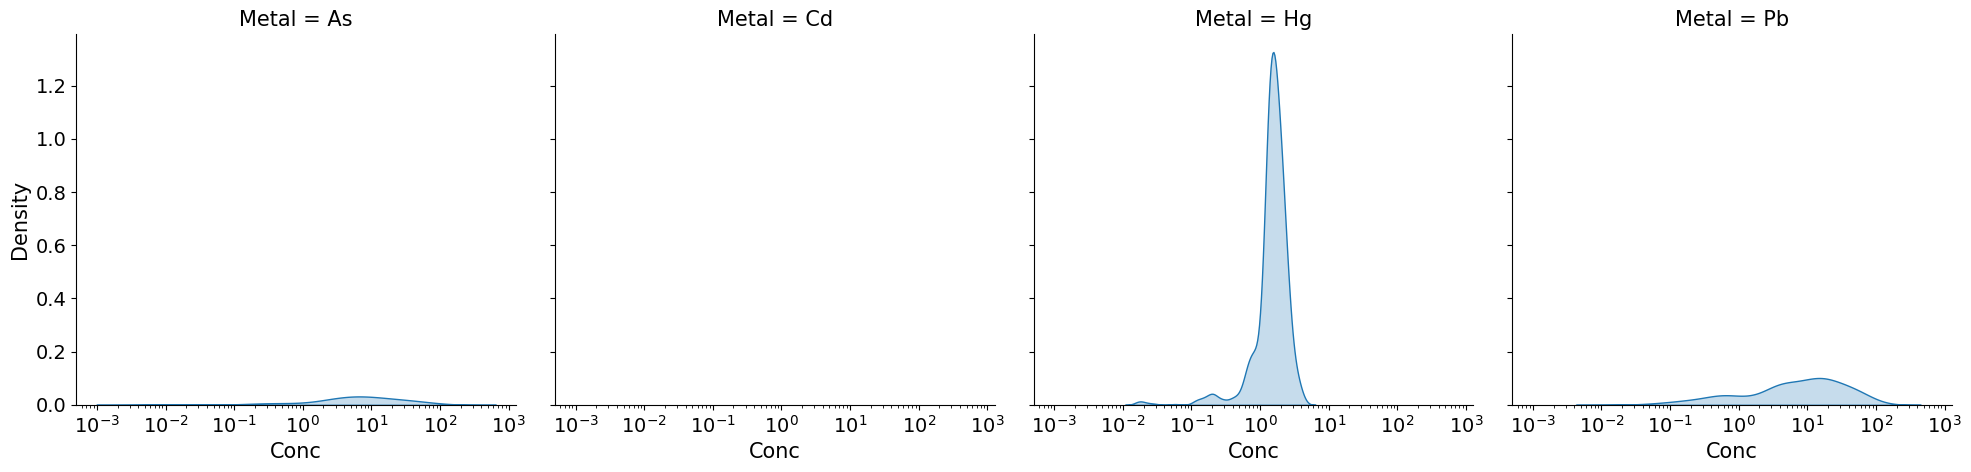

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.displot(data=df_met4, x="Conc", col="Metal", kind="kde", fill=True, log_scale=True)
plt.show()


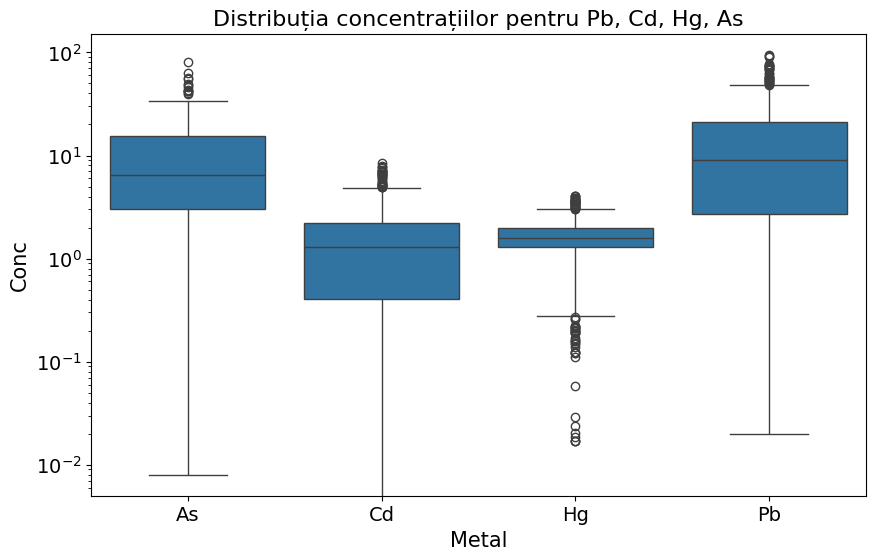

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df_met4, x="Metal", y="Conc")
plt.yscale("log")  # datele au outlieri mari
plt.title("Distribuția concentrațiilor pentru Pb, Cd, Hg, As")
plt.show()


🔥 10. Pivot matrix metal × categorie (pentru clusterizare sau heatmap)

In [ ]:
pivot_mat = df_met4.pivot_table(values="Conc",
                                index="Metal",
                                columns="Abbrev",
                                aggfunc="mean")
pivot_mat


Abbrev,BMs,CBp,CCPCf,CF,DFFS,FA,FAF,FCM,FFP,FM,FV,HSp,MMPr,OFP,PMPMP
Metal,,,,,,,,,,,,,,,
As,8.625500,0.620571,NaN,10.160000,17.188824,51.250000,7.64619,0.723500,5.342000,21.104762,42.400000,10.20000,NaN,11.891286,NaN
Cd,2.268219,0.150000,1.726012,3.960000,1.090000,NaN,0.18000,1.433027,0.857379,3.273462,0.535172,0.16400,0.975900,2.106000,NaN
Hg,0.951692,NaN,NaN,0.869800,0.631806,0.383000,0.22000,0.024000,1.698526,0.802059,2.431500,0.21000,1.291533,0.582417,0.01825
Pb,2.653333,0.471100,3.151000,20.118333,18.246270,55.666667,10.40250,18.013072,1.332167,23.388158,1.244192,20.44875,6.932517,13.489286,1.38700


# 🌟 1. Selectarea datelor pentru ANN – predict concentration


In [ ]:

import pandas as pd

metale_toxice = ["Pb", "Cd", "Hg", "As"]

df_ann = df_clean[df_clean["Metal"].isin(metale_toxice)].copy()

# eliminăm rândurile fără concentrație
df_ann = df_ann.dropna(subset=["Conc"])


# 🔥 0. Pregătirea datasetului pentru ML (selectare features)

In [ ]:
import pandas as pd

# Selectăm doar cele 4 metale toxice
metale_toxice = ["Pb", "Cd", "Hg", "As"]
df_ml = df_clean[df_clean["Metal"].isin(metale_toxice)].copy()

# Target = Risk decision
df_ml["Risk"] = df_ml["Risk_decision"].map({"serious":1, "not serious":0})

# Selectăm variabilele numerice
numeric_features = ["Conc", "Rank_Category"]

# Codificăm variabilele categoriale (one-hot)
categorical_features = ["Metal", "Product_category", "Notified_by", "Origin"]

df_ml_encoded = pd.get_dummies(df_ml[numeric_features + categorical_features + ["Risk"]],
                               drop_first=True)

df_ml_encoded.head()


,Conc,Rank_Category,Risk,Metal_Cd,Metal_Hg,Metal_Pb,Product_category_cereals and bakery products,"Product_category_cocoa and cocoa preparations, coffee and tea",Product_category_compound feeds,Product_category_crustaceans and products thereof,...,Origin_Turkey,Origin_Ukraine,Origin_United Arab Emirates,Origin_United Kingdom,Origin_United States,Origin_Unknown,Origin_Uruguay,Origin_Uzbekistan,Origin_Vietnam,Origin_Yemen
0,62.5,1.0,NaN,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,40.0,1.0,0.0,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,56.5,2.0,NaN,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,12.4,2.0,1.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3.2,2.0,NaN,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_bin = df_ml_encoded[df_ml_encoded["Risk"].notna()].copy()
X = df_bin.drop("Risk", axis=1)
y = df_bin["Risk"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [ ]:
# 1. eliminăm notificările 'undecided'
df_bin = df_ml_encoded[df_ml_encoded["Risk"].notna()].copy()

# 2. definim X și y
X = df_bin.drop("Risk", axis=1)
y = df_bin["Risk"].astype(int)

# 3. split balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [ ]:
df_bin.head()

,Conc,Rank_Category,Risk,Metal_Cd,Metal_Hg,Metal_Pb,Product_category_cereals and bakery products,"Product_category_cocoa and cocoa preparations, coffee and tea",Product_category_compound feeds,Product_category_crustaceans and products thereof,...,Origin_Turkey,Origin_Ukraine,Origin_United Arab Emirates,Origin_United Kingdom,Origin_United States,Origin_Unknown,Origin_Uruguay,Origin_Uzbekistan,Origin_Vietnam,Origin_Yemen
1,40.0,1.0,0.0,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,12.4,2.0,1.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,2.7,2.0,0.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,2.6,2.0,1.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,4.5,2.0,0.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_reg = df_ml_encoded.copy()

# eliminăm rândurile fără concentrație
df_reg = df_reg.dropna(subset=["Conc"])

y = df_reg["Conc"].astype(float)

# scoatem coloane care NU trebuie în features
X = df_reg.drop(columns=["Conc", "Risk"], errors="ignore")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="linear")  # regresie
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        37,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,337 (306.00 KB)

 Trainable params: 78,337 (306.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test MAE: {test_mae:.4f}")
print(f"Test MSE: {test_loss:.4f}")


Test MAE: 5.1010
Test MSE: 150.8932


In [ ]:
y_pred = model.predict(X_test_scaled).flatten()

df_pred = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

df_pred.head(15)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


,Actual,Predicted
0,2.140,0.019344
1,1.810,0.142813
2,1.270,0.514045
3,1.820,0.388116
4,0.760,0.015774
5,4.030,0.180024
6,1.150,0.142813
7,1.251,0.142813
8,0.082,0.343638
9,3.200,0.103573


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models, Input




In [ ]:
metale_toxice = ["Pb", "Cd", "Hg", "As"]

df_reg = df_clean[df_clean["Metal"].isin(metale_toxice)].copy()

# păstrăm doar rândurile cu concentrație
df_reg = df_reg.dropna(subset=["Conc"])


In [ ]:
num_features = [
    "Rank_Category",
    "Rank",
    "HM_limit_index",
    "Year"
]

cat_features = [
    "Metal",
    "Product_category",
    "Notified_by",
    "Origin"
]

df_encoded = pd.get_dummies(
    df_reg[num_features + cat_features],
    drop_first=True
)
X_all = df_encoded
y_all = df_reg["Conc"].astype(float)


In [ ]:
def train_ann_for_metal(metal_code):

    print("=" * 80)
    print(f"📌 Training ANN model for metal: {metal_code}")
    print("=" * 80)

    # -------------------------------------------------
    # 1. Selectare metal (fix pentru drop_first)
    # -------------------------------------------------
    metal_col = f"Metal_{metal_code}"

    if metal_col in X_all.columns:
        idx = X_all[metal_col] == 1
    else:
        # metal de referință (ex: As)
        idx = X_all.filter(like="Metal_").sum(axis=1) == 0

    X = X_all[idx].copy()
    y = y_all[idx].copy()

    if len(X) < 30:
        print(f"⚠️ Too few samples for {metal_code}, skipping.")
        return None

    # -------------------------------------------------
    # 2. Eliminăm coloanele Metal_* (nu ajută)
    # -------------------------------------------------
    X = X.drop(columns=X.filter(like="Metal_").columns)

    # -------------------------------------------------
    # 3. Train / Test split
    # -------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # -------------------------------------------------
    # 4. Standardizare
    # -------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # -------------------------------------------------
    # 5. ANN model
    # -------------------------------------------------
    model = models.Sequential([
        Input(shape=(X_train_scaled.shape[1],)),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(64, activation="relu"),

        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    # -------------------------------------------------
    # 6. Training
    # -------------------------------------------------
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    # -------------------------------------------------
    # 7. Evaluare
    # -------------------------------------------------
    test_mse, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

    print(f"MAE ({metal_code}): {test_mae:.3f}")
    print(f"MSE ({metal_code}): {test_mse:.3f}")

    # -------------------------------------------------
    # 8. Plot learning curve
    # -------------------------------------------------
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"Learning curve – {metal_code}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

    # -------------------------------------------------
    # 9. Actual vs Predicted
    # -------------------------------------------------
    y_pred = model.predict(X_test_scaled).flatten()

    plt.figure(figsize=(5, 5))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--"
    )
    plt.xlabel("Actual concentration")
    plt.ylabel("Predicted concentration")
    plt.title(f"Actual vs Predicted – {metal_code}")
    plt.show()

    return {
        "metal": metal_code,
        "model": model,
        "mae": test_mae,
        "mse": test_mse,
        "n_samples": len(y),
        "y_test": y_test.values,
        "y_pred": y_pred
    }

📌 Training ANN model for metal: Pb
MAE (Pb): 11.683
MSE (Pb): 326.139


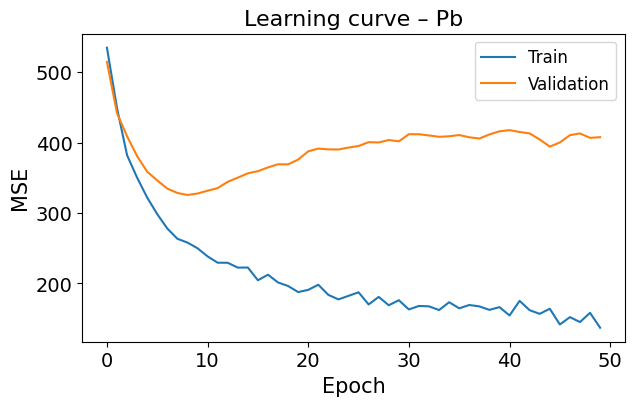

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


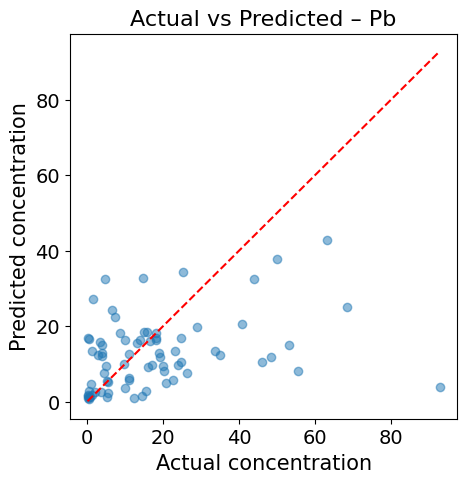

📌 Training ANN model for metal: Cd
MAE (Cd): 1.031
MSE (Cd): 2.383


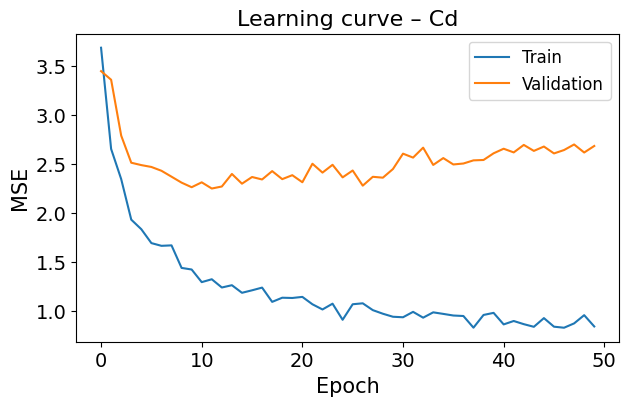

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


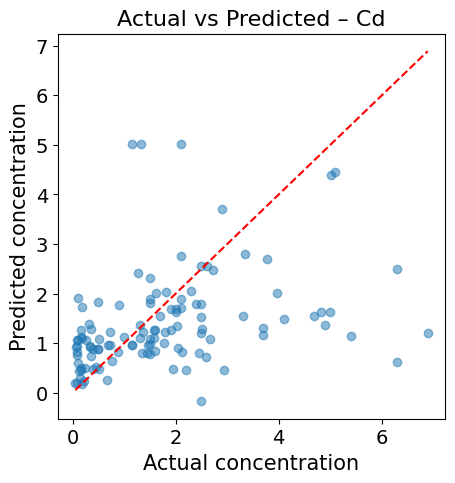

📌 Training ANN model for metal: Hg
MAE (Hg): 0.454
MSE (Hg): 0.401


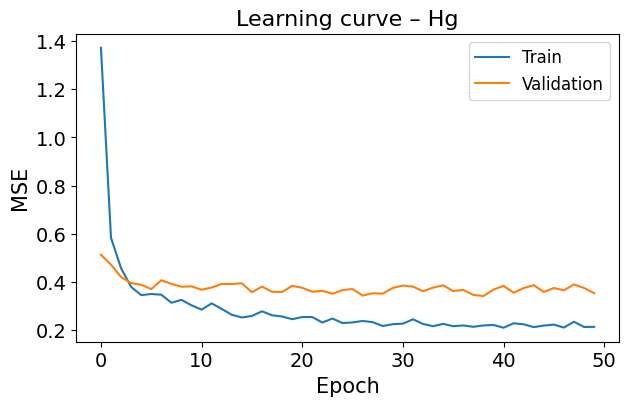

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


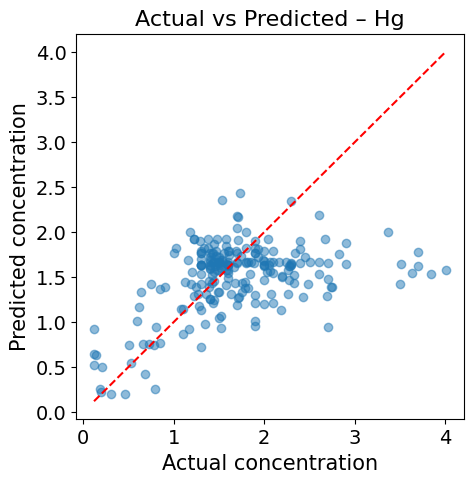

📌 Training ANN model for metal: As
MAE (As): 11.582
MSE (As): 288.510


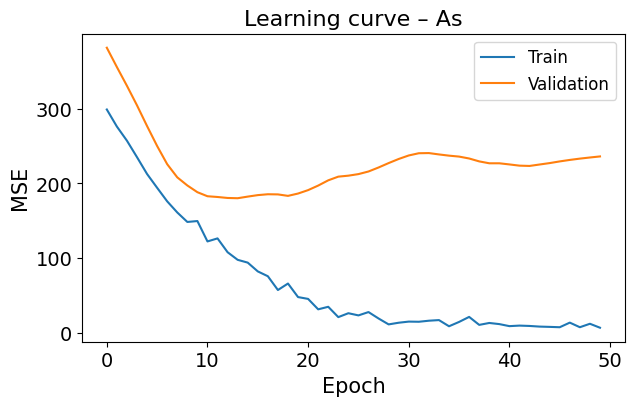

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


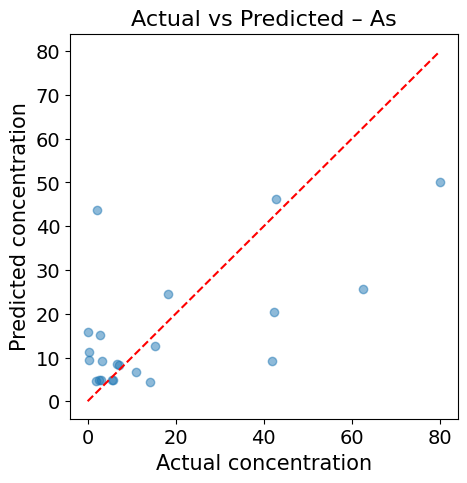

In [ ]:
results = {}

for m in ["Pb", "Cd", "Hg", "As"]:
    res = train_ann_for_metal(m)
    if res is not None:
        results[m] = res


In [ ]:
print("Metale existente în results:", list(results.keys()))


Metale existente în results: ['Pb', 'Cd', 'Hg', 'As']


In [ ]:
results = {}

📌 Training ANN model for metal: Pb
MAE (Pb): 11.959
MSE (Pb): 321.709


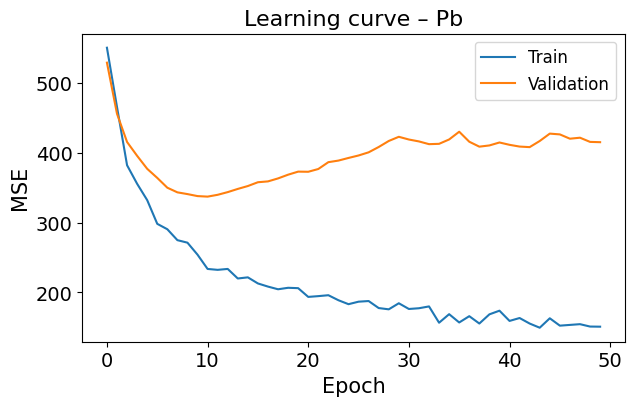

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


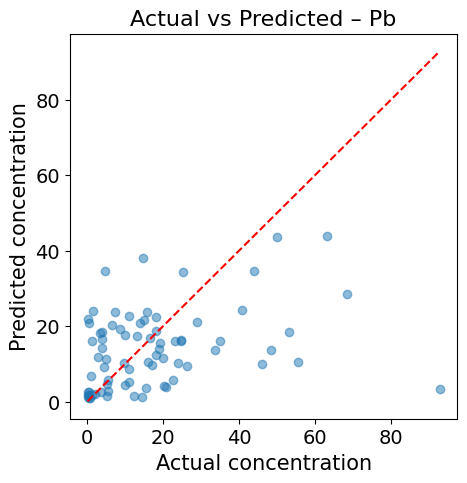

📌 Training ANN model for metal: Cd
MAE (Cd): 1.081
MSE (Cd): 2.540


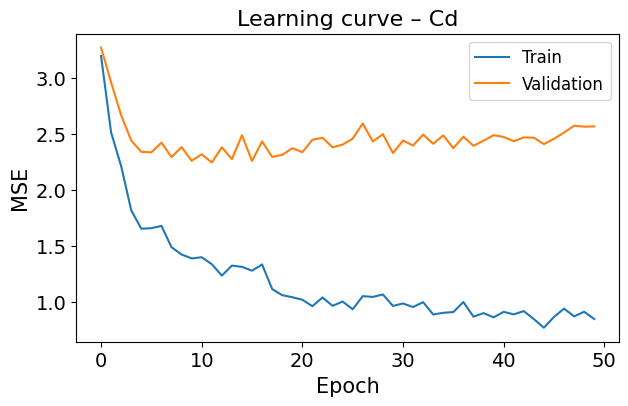

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


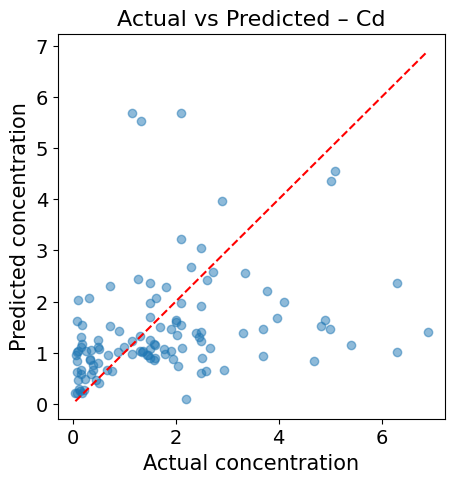

📌 Training ANN model for metal: Hg
MAE (Hg): 0.444
MSE (Hg): 0.395


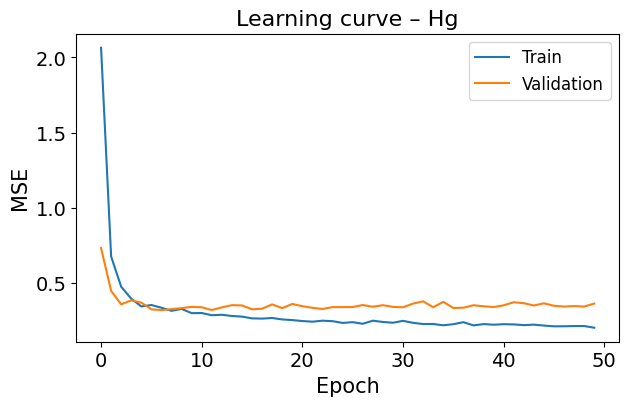

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


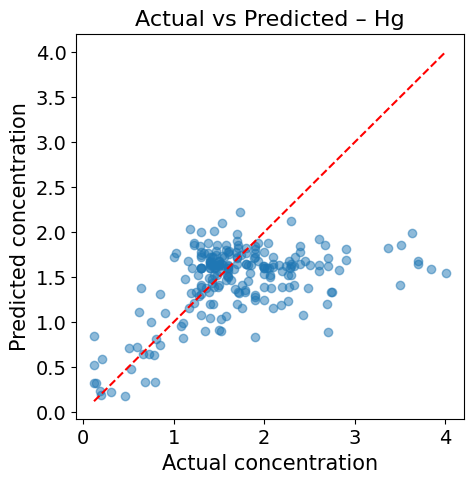

📌 Training ANN model for metal: As
MAE (As): 11.382
MSE (As): 299.191


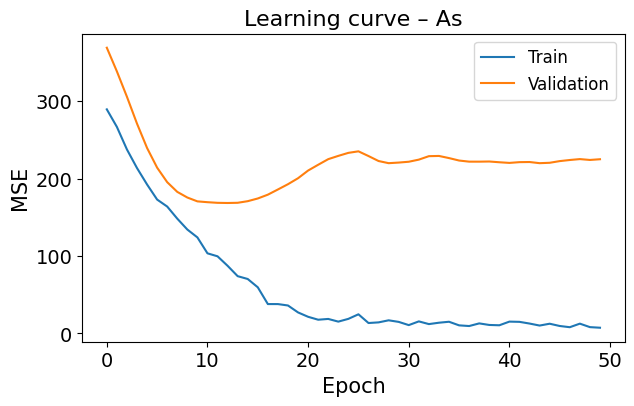

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


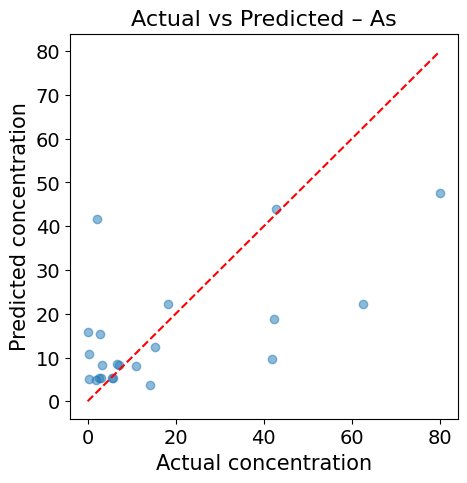

In [ ]:
target_metals = ["Pb", "Cd", "Hg", "As"]

for m in target_metals:
    res = train_ann_for_metal(m)
    results[m] = res



In [ ]:
for m in results:
    print(m, results[m].keys())


Pb dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])
Cd dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])
Hg dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])
As dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])


# Cod – FIGURA X.1 (Hg + Cd)

In [ ]:
def plot_residuals(results, metals, title):
    plt.figure(figsize=(6, 4))

    for metal in metals:
        residuals = results[metal]["y_test"] - results[metal]["y_pred"]
        plt.hist(
            residuals,
            bins=25,
            alpha=0.5,
            label=metal
        )

    plt.xlabel("Residuals (mg/kg)")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


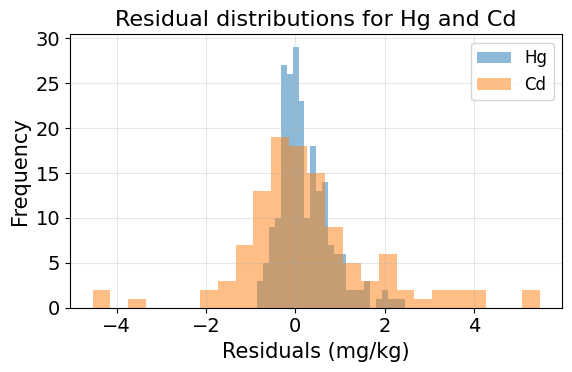

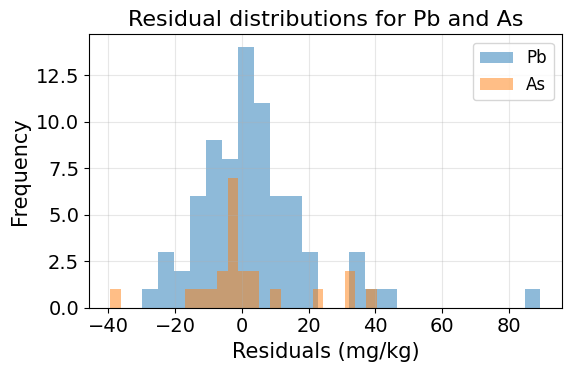

In [ ]:
plot_residuals(
    results,
    metals=["Hg", "Cd"],
    title="Residual distributions for Hg and Cd"
)

plot_residuals(
    results,
    metals=["Pb", "As"],
    title="Residual distributions for Pb and As"
)


In [ ]:
for m in results:
    print(m, results[m].keys())


Pb dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])
Cd dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])
Hg dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])
As dict_keys(['metal', 'model', 'mae', 'mse', 'n_samples', 'y_test', 'y_pred'])


In [ ]:
def plot_residuals(results, metals, title):
    plt.figure(figsize=(6, 4))

    for metal in metals:
        residuals = results[metal]["y_test"] - results[metal]["y_pred"]
        plt.hist(
            residuals,
            bins=25,
            alpha=0.5,
            label=metal
        )

    plt.xlabel("Residuals (mg/kg)")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


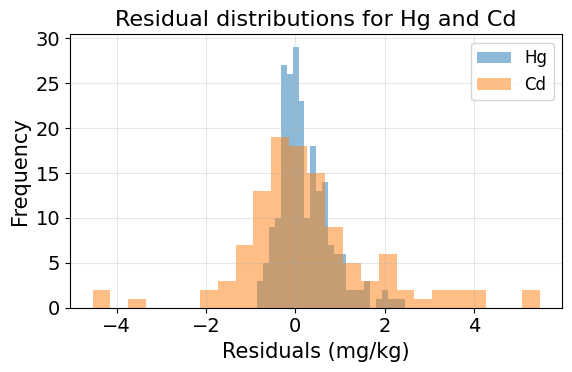

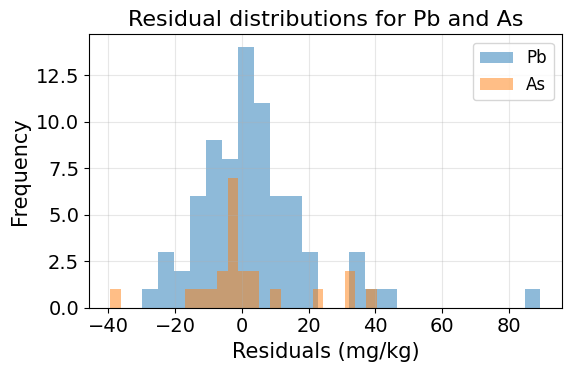

In [ ]:
plot_residuals(
    results,
    metals=["Hg", "Cd"],
    title="Residual distributions for Hg and Cd"
)

plot_residuals(
    results,
    metals=["Pb", "As"],
    title="Residual distributions for Pb and As"
)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Construim dataframe cu erori per observație
# -------------------------------------------------
rows = []

for metal, res in results.items():

    y_true = res["y_test"]
    y_pred = res["y_pred"]

    errors = np.abs(y_true - y_pred)

    # extragem Rank_Category corespunzător setului de test
    # (folosim df_reg în aceeași ordine ca X/y inițial)
    df_m = df_reg[df_reg["Metal"] == metal].iloc[-len(y_true):].copy()

    for err, rank in zip(errors, df_m["Rank_Category"].values):
        rows.append({
            "Metal": metal,
            "Rank_Category": rank,
            "Absolute_Error": err
        })

df_err = pd.DataFrame(rows)


In [ ]:
df_err["Risk_Group"] = pd.cut(
    df_err["Rank_Category"],
    bins=[0, 2, 4, 6],
    labels=["High-risk", "Medium-risk", "Low-risk"]
)


<Figure size 700x500 with 0 Axes>

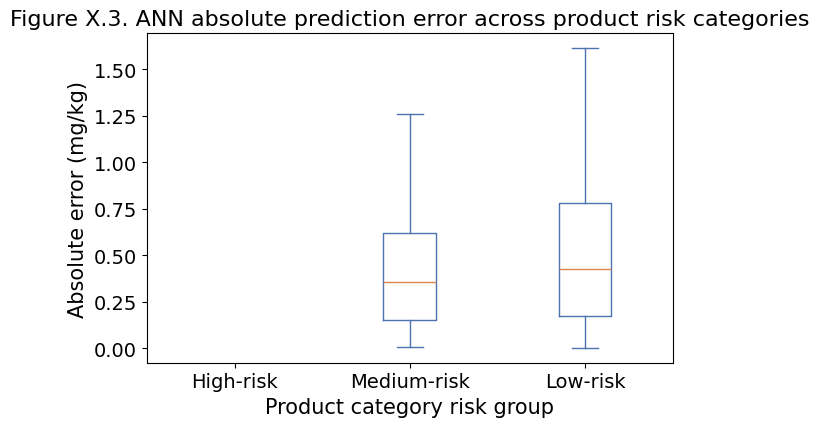

In [ ]:
plt.figure(figsize=(7,5))

df_err.boxplot(
    column="Absolute_Error",
    by="Risk_Group",
    grid=False,
    showfliers=False,
    color=dict(boxes="#4C72B0",
               whiskers="#4C72B0",
               medians="#DD8452",
               caps="#4C72B0")
)

plt.suptitle("")
plt.title("Figure X.3. ANN absolute prediction error across product risk categories")
plt.xlabel("Product category risk group")
plt.ylabel("Absolute error (mg/kg)")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ----------------------------------------------------
# 1. Datele de intrare (limite metale / categorie produs)
# ----------------------------------------------------
data = {
    "Category": ["FA", "FM", "CF", "FFP", "BMs", "DFFS", "OFP",
                 "FV", "MMPr", "CCPCf", "FAF", "CBP", "HSp", "PMPMP", "FCM"],
    "Pb": [205, 17.5, 105, 0.3, 0.9, 3, 0.3, 0.42, 0.15, np.nan, 1.05, 0.2, 1.3, 0.15, 0.01],
    "Cd": [16, 5.5, 7.75, 0.15, 0.75, 1, 0.02, 0.61, 0.525, 0.45, np.nan, 0.125, np.nan, np.nan, 0.005],
    "Hg": [np.nan, 2.55, 0.2, 1, 0.4, 0.1, 0.1, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.002],
    "As": [65, 21, 16, np.nan, np.nan, np.nan, 0.015, np.nan, np.nan, np.nan, 0.5, 0.165, np.nan, np.nan, 0.01],
    "Cr": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.01],
    "Ni": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.02]
}

df = pd.DataFrame(data)

# ----------------------------------------------------
# 2. Agregare limite metale (sumă pe categorie)
# ----------------------------------------------------
metal_cols = ["Pb", "Cd", "Hg", "As", "Cr", "Ni"]
df["T_raw"] = df[metal_cols].sum(axis=1, skipna=True)

# ----------------------------------------------------
# 3. Normalizare (Min–Max)
# ----------------------------------------------------
scaler = MinMaxScaler()
df["T_sum"] = scaler.fit_transform(df[["T_raw"]])

# ----------------------------------------------------
# 4. Ranking (1 = cea mai importantă / riscantă categorie)
# ----------------------------------------------------
df["Rank"] = df["T_sum"].rank(ascending=False, method="dense").astype(int)

# ----------------------------------------------------
# 5. Sortare finală
# ----------------------------------------------------
df_final = df.sort_values("Rank")

print(df_final[["Category", "T_sum", "Rank"] + metal_cols])


   Category     T_sum  Rank      Pb      Cd     Hg      As    Cr    Ni
0        FA  1.000000     1  205.00  16.000    NaN  65.000   NaN   NaN
2        CF  0.450765     2  105.00   7.750  0.200  16.000   NaN   NaN
1        FM  0.162595     3   17.50   5.500  2.550  21.000   NaN   NaN
5      DFFS  0.014139     4    3.00   1.000  0.100     NaN   NaN   NaN
4       BMs  0.006970     5    0.90   0.750  0.400     NaN   NaN   NaN
10      FAF  0.005221     6    1.05     NaN    NaN   0.500   NaN   NaN
3       FFP  0.004872     7    0.30   0.150  1.000     NaN   NaN   NaN
12      HSp  0.004347     8    1.30     NaN    NaN     NaN   NaN   NaN
7        FV  0.003403     9    0.42   0.610    NaN     NaN   NaN   NaN
8      MMPr  0.002161    10    0.15   0.525    NaN     NaN   NaN   NaN
11      CBP  0.001514    11    0.20   0.125    NaN   0.165   NaN   NaN
9     CCPCf  0.001374    12     NaN   0.450    NaN     NaN   NaN   NaN
6       OFP  0.001322    13    0.30   0.020  0.100   0.015   NaN   NaN
13    

In [ ]:
df_err["Rank_Category"].describe()




,Rank_Category
count,432.000000
mean,8.381944
std,5.055602
min,0.000000
25%,4.000000
50%,5.000000
75%,15.000000
max,15.000000


In [ ]:
df_err["Rank_Category"].value_counts().sort_index()


,count
Rank_Category,
0.0,7
4.0,151
5.0,64
6.0,31
7.0,12
8.0,4
9.0,3
11.0,6
13.0,2


In [ ]:
def map_risk_group_3(rank):
    if rank <= 4:
        return "Permissive regulatory categories"
    elif rank <= 10:
        return "Intermediate regulatory categories"
    else:
        return "Strict regulatory categories"

df_err["Risk_Group_3"] = df_err["Rank_Category"].apply(map_risk_group_3)


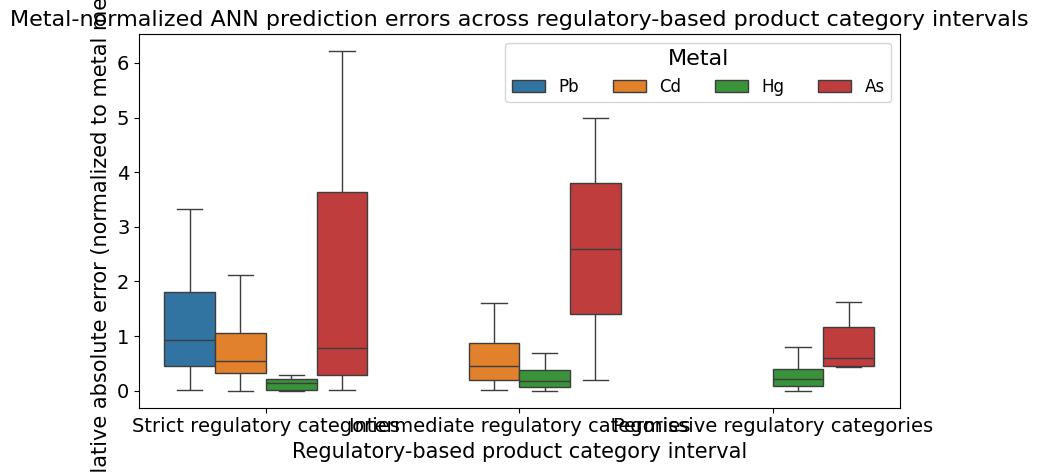

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1. Calculăm eroarea relativă (normalizare metal-wise)
# -------------------------------------------------
df_err["Relative_Error"] = np.nan

for metal in df_err["Metal"].unique():
    median_conc = df_reg[df_reg["Metal"] == metal]["Conc"].median()
    idx = df_err["Metal"] == metal
    df_err.loc[idx, "Relative_Error"] = (
        df_err.loc[idx, "Absolute_Error"] / median_conc
    )

# -------------------------------------------------
# 2. Plot – FIGURA S.X4
# -------------------------------------------------
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_err,
    x="Risk_Group_3",
    y="Relative_Error",
    hue="Metal",
    showfliers=False
)


plt.title(
    "Metal-normalized ANN prediction errors across regulatory-based product category intervals"
)
plt.xlabel("Regulatory-based product category interval")
plt.ylabel("Relative absolute error (normalized to metal median)")
plt.legend(title="Metal", ncol=4)
plt.tight_layout()
plt.show()



In [ ]:
df_err["Risk_Group_3"].value_counts()

df_err.groupby("Risk_Group_3")["Absolute_Error"].describe()


,count,mean,std,min,25%,50%,75%,max
Risk_Group_3,,,,,,,,
Intermediate regulatory categories,114.0,0.984793,3.133866,0.001987,0.160405,0.414964,0.742711,32.456928
Permissive regulatory categories,158.0,0.733875,1.618171,0.003921,0.153735,0.371795,0.666405,15.918284
Strict regulatory categories,160.0,7.127226,11.558728,0.001082,0.549003,2.023252,8.947685,89.459647


In [ ]:
from scipy.stats import kruskal

groups = [
    df_err[df_err["Risk_Group_3"] == g]["Absolute_Error"]
    for g in df_err["Risk_Group_3"].unique()
]

stat, p = kruskal(*groups)
print(f"Kruskal–Wallis H = {stat:.3f}, p-value = {p:.4e}")


Kruskal–Wallis H = 100.471, p-value = 1.5239e-22


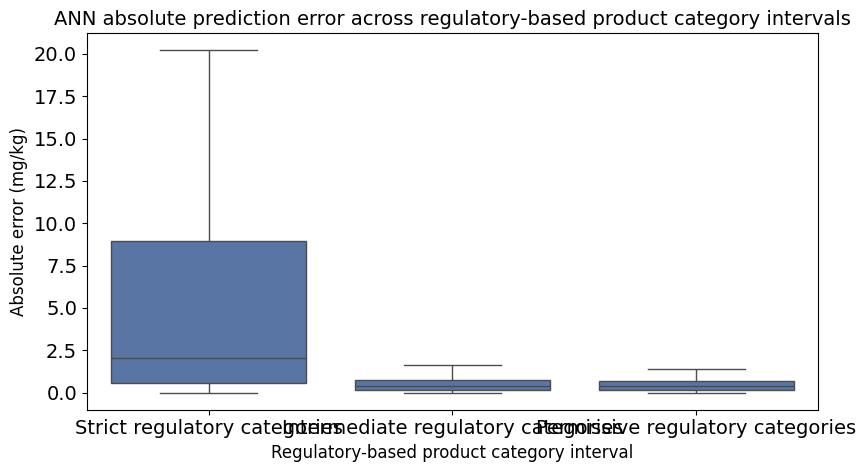

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

# Boxplot
sns.boxplot(
    data=df_err,
    x="Risk_Group_3",
    y="Absolute_Error",
    color="#4C72B0",
    showfliers=False
)



plt.title(
    "ANN absolute prediction error across regulatory-based product category intervals",
    fontsize=14
)
plt.xlabel("Regulatory-based product category interval", fontsize=12)
plt.ylabel("Absolute error (mg/kg)", fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
desc_err = df_err.groupby("Risk_Group_3")["Absolute_Error"].describe()
print(desc_err)


                                    count      mean        std       min  \
Risk_Group_3                                                               
Intermediate regulatory categories  114.0  0.984793   3.133866  0.001987   
Permissive regulatory categories    158.0  0.733875   1.618171  0.003921   
Strict regulatory categories        160.0  7.127226  11.558728  0.001082   

                                         25%       50%       75%        max  
Risk_Group_3                                                                 
Intermediate regulatory categories  0.160405  0.414964  0.742711  32.456928  
Permissive regulatory categories    0.153735  0.371795  0.666405  15.918284  
Strict regulatory categories        0.549003  2.023252  8.947685  89.459647  


In [ ]:
from scipy.stats import kruskal

groups = [
    df_err[df_err["Risk_Group_3"] == g]["Absolute_Error"]
    for g in df_err["Risk_Group_3"].unique()
]

stat, p = kruskal(*groups)
print(stat, p)



100.47113976598072 1.5239446883597841e-22


/tmp/ipython-input-487559165.py:55: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.stripplot(


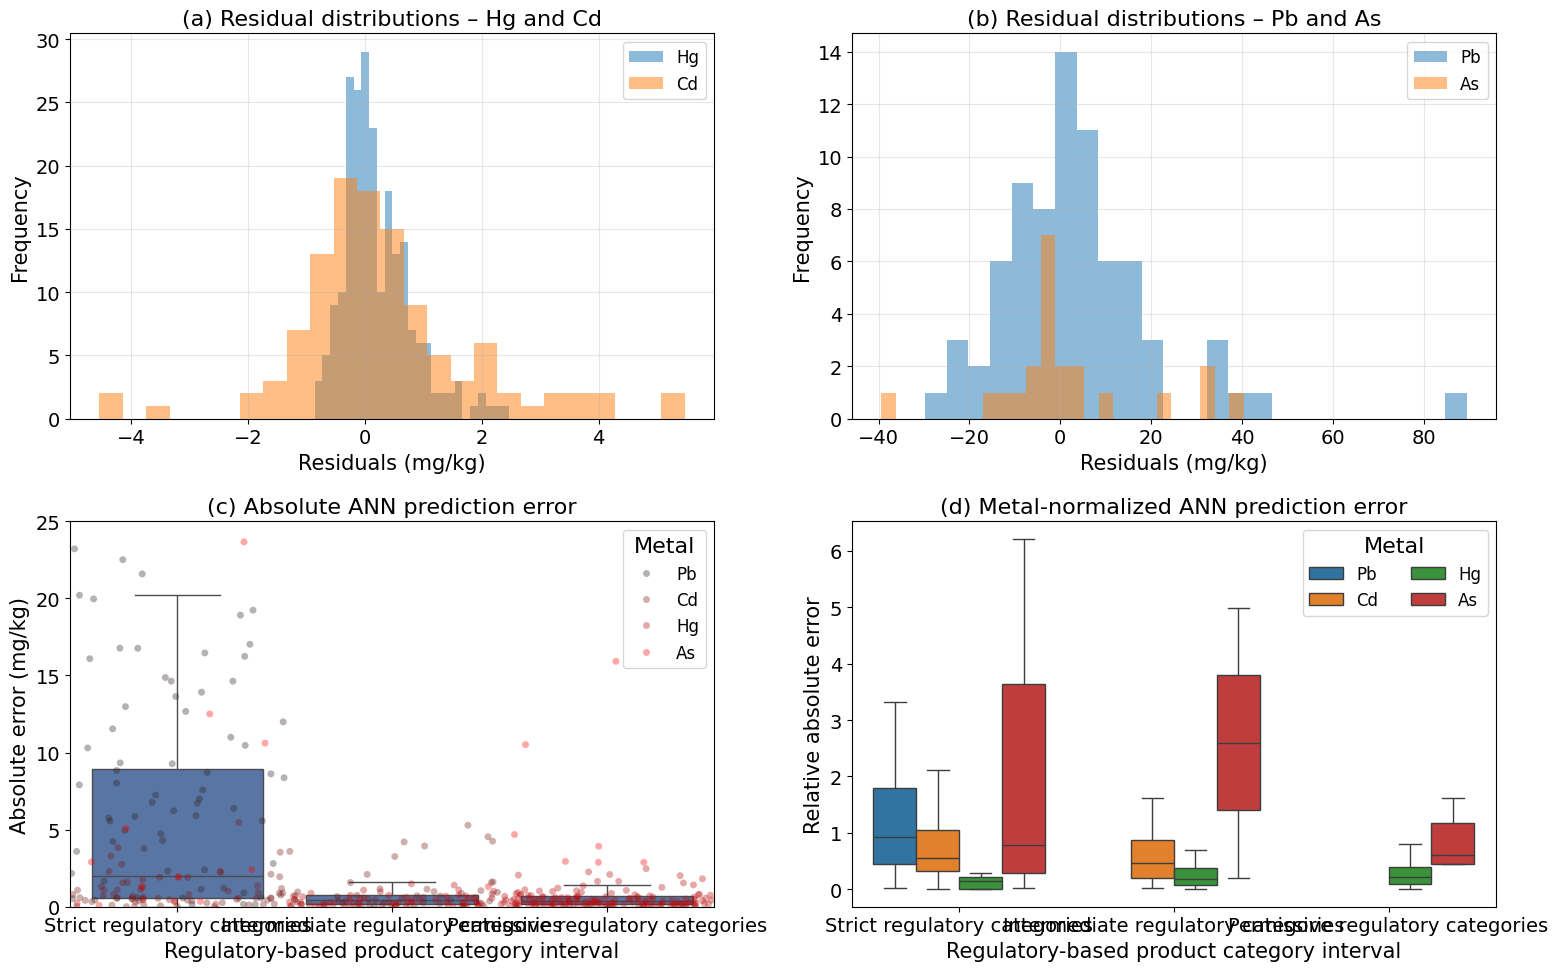

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# =================================================
# (a) Residuals – Hg & Cd
# =================================================
for metal in ["Hg", "Cd"]:
    residuals = results[metal]["y_test"] - results[metal]["y_pred"]
    axes[0, 0].hist(
        residuals,
        bins=25,
        alpha=0.5,
        label=metal
    )

axes[0, 0].set_title("(a) Residual distributions – Hg and Cd")
axes[0, 0].set_xlabel("Residuals (mg/kg)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# =================================================
# (b) Residuals – Pb & As
# =================================================
for metal in ["Pb", "As"]:
    residuals = results[metal]["y_test"] - results[metal]["y_pred"]
    axes[0, 1].hist(
        residuals,
        bins=25,
        alpha=0.5,
        label=metal
    )

axes[0, 1].set_title("(b) Residual distributions – Pb and As")
axes[0, 1].set_xlabel("Residuals (mg/kg)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# =================================================
# (c) Absolute ANN error vs regulatory intervals
# =================================================
sns.boxplot(
    data=df_err,
    x="Risk_Group_3",
    y="Absolute_Error",
    color="#4C72B0",
    showfliers=False,
    ax=axes[1, 0]
)

sns.stripplot(
    data=df_err,
    x="Risk_Group_3",
    y="Absolute_Error",
    hue="Metal",
    color="red",
    size=5,
    jitter=0.5,
    alpha=0.35,
    ax=axes[1, 0]
)
axes[1, 0].set_ylim(0, 25)
axes[1, 0].set_title("(c) Absolute ANN prediction error")
axes[1, 0].set_xlabel("Regulatory-based product category interval")
axes[1, 0].set_ylabel("Absolute error (mg/kg)")

# =================================================
# (d) Relative (normalized) ANN error vs intervals
# =================================================
sns.boxplot(
    data=df_err,
    x="Risk_Group_3",
    y="Relative_Error",
    hue="Metal",
    showfliers=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("(d) Metal-normalized ANN prediction error")
axes[1, 1].set_xlabel("Regulatory-based product category interval")
axes[1, 1].set_ylabel("Relative absolute error")
axes[1, 1].legend(title="Metal", ncol=2)



# =================================================
# Final layout
# =================================================
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# SALVARE MDPI (TIFF 300 DPI)
# -----------------------------------------------------
fig.savefig("/content/drive/MyDrive/heavy_metals/figure_300dpi.tiff",
            dpi=300, format='tiff')

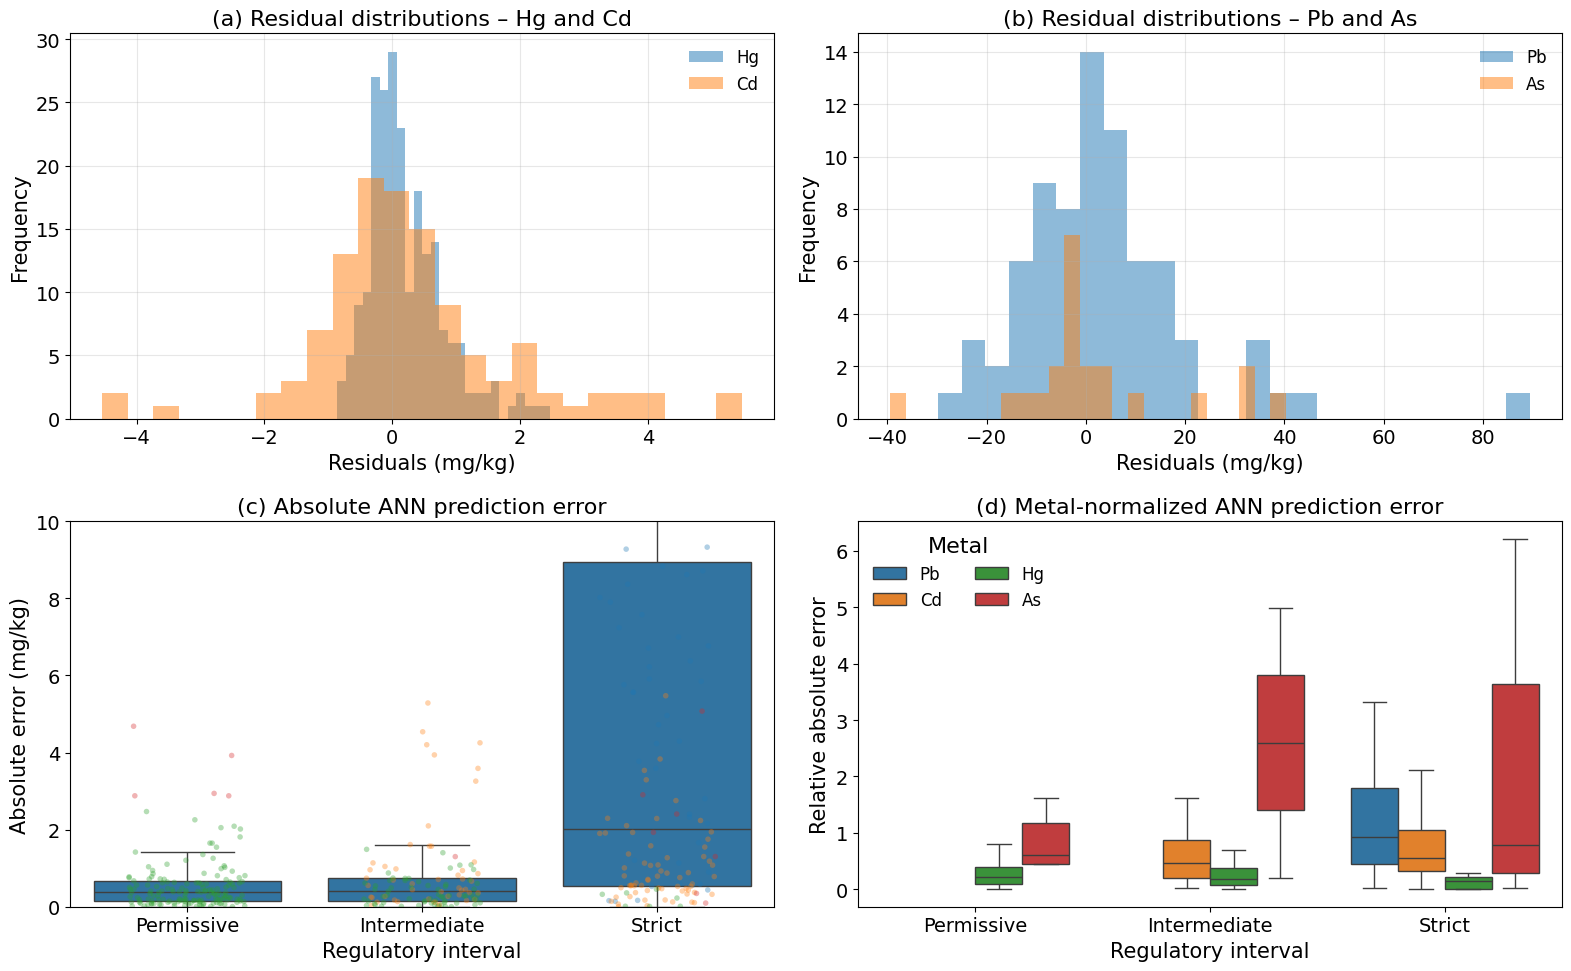

Saved: /content/drive/MyDrive/heavy_metals/Figure_ANN_panels_300dpi.tiff


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 0) Abrevieri + ordine fixă
# -------------------------------------------------
risk_map = {
    "Permissive regulatory categories": "Permissive",
    "Intermediate regulatory categories": "Intermediate",
    "Strict regulatory categories": "Strict"
}
risk_order = ["Permissive", "Intermediate", "Strict"]

df_plot = df_err.copy()
df_plot["Risk_short"] = df_plot["Risk_Group_3"].map(risk_map)

# -------------------------------------------------
# 1) Figure
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# =================================================
# (a) Residuals – Hg & Cd
# =================================================
for metal in ["Hg", "Cd"]:
    residuals = results[metal]["y_test"] - results[metal]["y_pred"]
    axes[0, 0].hist(residuals, bins=25, alpha=0.5, label=metal)

axes[0, 0].set_title("(a) Residual distributions – Hg and Cd")
axes[0, 0].set_xlabel("Residuals (mg/kg)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(alpha=0.3)

# =================================================
# (b) Residuals – Pb & As
# =================================================
for metal in ["Pb", "As"]:
    residuals = results[metal]["y_test"] - results[metal]["y_pred"]
    axes[0, 1].hist(residuals, bins=25, alpha=0.5, label=metal)

axes[0, 1].set_title("(b) Residual distributions – Pb and As")
axes[0, 1].set_xlabel("Residuals (mg/kg)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(alpha=0.3)

# =================================================
# (c) Absolute ANN error vs regulatory intervals (abrevieri)
# =================================================
sns.boxplot(
    data=df_plot,
    x="Risk_short",
    y="Absolute_Error",
    order=risk_order,
    showfliers=False,
    ax=axes[1, 0]
)

sns.stripplot(
    data=df_plot,
    x="Risk_short",
    y="Absolute_Error",
    order=risk_order,
    hue="Metal",
    jitter=0.25,
    alpha=0.35,
    size=4,
    ax=axes[1, 0]
)
axes[1, 0].set_ylim(0, 10)  # zoom; dacă vrei full, scoate linia asta

axes[1, 0].set_title("(c) Absolute ANN prediction error")
axes[1, 0].set_xlabel("Regulatory interval")
axes[1, 0].set_ylabel("Absolute error (mg/kg)")

# scoatem legenda din panel (c) ca să nu se dubleze
axes[1, 0].legend_.remove()

# =================================================
# (d) Relative (normalized) ANN error vs intervals (abrevieri)
# =================================================
sns.boxplot(
    data=df_plot,
    x="Risk_short",
    y="Relative_Error",
    order=risk_order,
    hue="Metal",
    showfliers=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("(d) Metal-normalized ANN prediction error")
axes[1, 1].set_xlabel("Regulatory interval")
axes[1, 1].set_ylabel("Relative absolute error")

# legendă curată (panel d)
axes[1, 1].legend(title="Metal", ncol=2, frameon=False)

# -------------------------------------------------
# Final layout + salvare
# -------------------------------------------------
plt.tight_layout()

out_path = "/content/drive/MyDrive/heavy_metals/Figure_ANN_panels_300dpi.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")

plt.show()
print("Saved:", out_path)


In [ ]:
df_exc = df_clean.copy()

df_exc["Exceedance"] = (df_exc["Conc"] > df_exc["HM_limit_index"]).astype(int)

df_exc["Exceedance"].value_counts()



,count
Exceedance,
1,2910
0,76


In [ ]:
df_err = df_err.drop(columns=["Risk_Group"], errors="ignore")
df_err.head(10)

,Metal,Rank_Category,Absolute_Error,Risk_Group_3,Relative_Error
0,Pb,15.0,16.238773,Strict regulatory categories,1.810343
1,Pb,15.0,1.205438,Strict regulatory categories,0.134385
2,Pb,15.0,7.903287,Strict regulatory categories,0.881080
3,Pb,15.0,4.960766,Strict regulatory categories,0.553040
4,Pb,15.0,7.241611,Strict regulatory categories,0.807315
5,Pb,15.0,14.631875,Strict regulatory categories,1.631201
6,Pb,15.0,9.330319,Strict regulatory categories,1.040169
7,Pb,15.0,0.164406,Strict regulatory categories,0.018328
8,Pb,15.0,20.205336,Strict regulatory categories,2.252546
9,Pb,15.0,2.323925,Strict regulatory categories,0.259077


In [ ]:
import numpy as np
import pandas as pd

df_clean["Rank_Category"] = pd.to_numeric(df_clean["Rank_Category"], errors="coerce")

def risk_group_3(rank):
    if pd.isna(rank):
        return np.nan
    rank = int(rank)
    if rank <= 4:
        return "Permissive regulatory categories"
    elif rank <= 10:
        return "Intermediate regulatory categories"
    else:
        return "Strict regulatory categories"

df_clean["Risk_Group_3"] = df_clean["Rank_Category"].apply(risk_group_3)

df_clean["Risk_Group_3"].value_counts(dropna=False)

df_clean.head()

,Metal,Product_category,Abbrev,Rank,Notified_by,Year,Product_type,Origin,Risk_decision,Conc,Metal_group,HM_limit_index,Rank_Category,Metal_color,Risk_Group_3
0,As,feed additives,FA,1,Italy,2012,feed,Poland,undecided,62.5,G2_intermediate,3.000000,1.0,orange,Permissive regulatory categories
1,As,feed additives,FA,1,Italy,2017,feed,United States,not serious,40.0,G2_intermediate,3.000000,1.0,orange,Permissive regulatory categories
2,As,feed materials,FM,2,Italy,2011,feed,Austria,undecided,56.5,G2_intermediate,1.751839,2.0,orange,Permissive regulatory categories
3,As,feed materials,FM,2,Italy,2013,feed,Austria,serious,12.4,G2_intermediate,1.751839,2.0,orange,Permissive regulatory categories
4,As,feed materials,FM,2,Italy,2011,feed,Belgium,undecided,3.2,G2_intermediate,1.751839,2.0,orange,Permissive regulatory categories


In [ ]:
df_exc = df_clean.copy()

df_exc["Exceedance"] = (
    df_exc["Conc"].astype(float) > df_exc["HM_limit_index"].astype(float)
).astype(int)

df_exc[["Metal","Rank_Category","Risk_Group_3","Conc","HM_limit_index","Exceedance"]].head()


,Metal,Rank_Category,Risk_Group_3,Conc,HM_limit_index,Exceedance
0,As,1.0,Permissive regulatory categories,62.5,3.000000,1
1,As,1.0,Permissive regulatory categories,40.0,3.000000,1
2,As,2.0,Permissive regulatory categories,56.5,1.751839,1
3,As,2.0,Permissive regulatory categories,12.4,1.751839,1
4,As,2.0,Permissive regulatory categories,3.2,1.751839,1


In [ ]:
# A) MPL exceedance summary (notification-level)
mpl_summary = (
    df_exc
    .groupby(["Risk_Group_3", "Metal"], dropna=False)
    .agg(
        n_records=("Conc", "count"),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean())
    )
    .reset_index()
)

# B) ANN instability summary (ANN-error level)
ann_summary = (
    df_err
    .groupby(["Risk_Group_3", "Metal"], dropna=False)
    .agg(
        n_ann=("Absolute_Error", "count"),
        mean_abs_error=("Absolute_Error", "mean"),
        median_abs_error=("Absolute_Error", "median"),
        q75_abs_error=("Absolute_Error", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

# C) Merge safe at stratum level
early_warning_final = mpl_summary.merge(
    ann_summary,
    on=["Risk_Group_3", "Metal"],
    how="left"
)

# sanity checks
print("len(df_exc) =", len(df_exc))
print("sum(n_records) =", early_warning_final["n_records"].sum())
early_warning_final.sort_values(["Risk_Group_3","Metal"])


len(df_exc) = 2986
sum(n_records) = 2986


,Risk_Group_3,Metal,n_records,exceed_rate_pct,n_ann,mean_abs_error,median_abs_error,q75_abs_error
0,Intermediate regulatory categories,As,41,97.560976,2.0,16.878722,16.878722,24.667825
1,Intermediate regulatory categories,Cd,350,99.142857,49.0,1.103341,0.594795,1.137039
2,Intermediate regulatory categories,Co,1,100.000000,NaN,NaN,NaN,NaN
3,Intermediate regulatory categories,Cr,1,100.000000,NaN,NaN,NaN,NaN
4,Intermediate regulatory categories,Cu,13,100.000000,NaN,NaN,NaN,NaN
5,Intermediate regulatory categories,Fe,1,100.000000,NaN,NaN,NaN,NaN
6,Intermediate regulatory categories,Hg,63,96.825397,63.0,0.388019,0.281962,0.590740
7,Intermediate regulatory categories,Ni,3,100.000000,NaN,NaN,NaN,NaN
8,Intermediate regulatory categories,Pb,136,100.000000,NaN,NaN,NaN,NaN
9,Intermediate regulatory categories,Sb,2,100.000000,NaN,NaN,NaN,NaN


In [ ]:
print("Risk_Group_3 in df_exc?", "Risk_Group_3" in df_exc.columns)
print(df_exc.columns)


Risk_Group_3 in df_exc? True
Index(['Metal', 'Product_category', 'Abbrev', 'Rank', 'Notified_by', 'Year',
       'Product_type', 'Origin', 'Risk_decision', 'Conc', 'Metal_group',
       'HM_limit_index', 'Rank_Category', 'Metal_color', 'Risk_Group_3',
       'Exceedance'],
      dtype='object')


In [ ]:
def map_risk_group(rank):
    if rank <= 4:
        return "Permissive regulatory categories"
    elif rank <= 10:
        return "Intermediate regulatory categories"
    else:
        return "Strict regulatory categories"

df_exc["Risk_Group_3"] = df_exc["Rank_Category"].apply(map_risk_group)


In [ ]:
# A) MPL exceedances (din df_exc)
mpl_summary = (
    df_exc
    .groupby(["Risk_Group_3","Metal"])
    .agg(
        n_records=("Conc","count"),
        exceed_rate_pct=("Exceedance", lambda x: 100*x.mean())
    )
    .reset_index()
)

# B) ANN instability (din df_err)
ann_summary = (
    df_err
    .groupby(["Risk_Group_3","Metal"])
    .agg(
        n_ann=("Absolute_Error","count"),
        q75_abs_error=("Absolute_Error", lambda x: x.quantile(0.75)),
        mean_abs_error=("Absolute_Error","mean"),
        median_abs_error=("Absolute_Error","median")
    )
    .reset_index()
)

# C) tabel final pentru heatmap / Table 5
early_warning_final = mpl_summary.merge(
    ann_summary,
    on=["Risk_Group_3","Metal"],
    how="left"
)

# sanity check (obligatoriu)
print("len(df_exc):", len(df_exc))
print("sum n_records:", early_warning_final["n_records"].sum())


len(df_exc): 2986
sum n_records: 2986


In [ ]:
ann_summary = (
    df_err
    .groupby(["Risk_Group_3","Metal"])
    .agg(
        n_ann=("Absolute_Error","count"),
        q75_abs_error=("Absolute_Error", lambda x: x.quantile(0.75)),
        mean_abs_error=("Absolute_Error","mean"),
        median_abs_error=("Absolute_Error","median")
    )
    .reset_index()
)


In [ ]:
early_warning_final = mpl_summary.merge(
    ann_summary,
    on=["Risk_Group_3","Metal"],
    how="left"
)

# verificare consistență: suma n_records trebuie să fie len(df_exc)
print("Sum n_records:", early_warning_final["n_records"].sum())
print("len(df_exc):", len(df_exc))


Sum n_records: 2986
len(df_exc): 2986


In [ ]:
print("df_clean:", df_clean.shape)
print("df_exc:", df_exc.shape)

# dubluri exacte
print("Exact duplicated rows in df_exc:", df_exc.duplicated().sum())

# cheie compusă (dacă nu ai ID)
key_cols = ["Metal","Abbrev","Year","Origin","Notified_by","Product_type",
            "Risk_decision","Conc","HM_limit_index","Rank_Category"]

missing = [c for c in key_cols if c not in df_exc.columns]
print("Missing key cols:", missing)

if len(missing) == 0:
    print("Duplicates on key_cols:", df_exc.duplicated(subset=key_cols).sum())
    print("Unique rows by key_cols:", df_exc.drop_duplicates(subset=key_cols).shape)


df_clean: (2986, 15)
df_exc: (2986, 16)
Exact duplicated rows in df_exc: 113
Missing key cols: []
Duplicates on key_cols: 113
Unique rows by key_cols: (2873, 16)


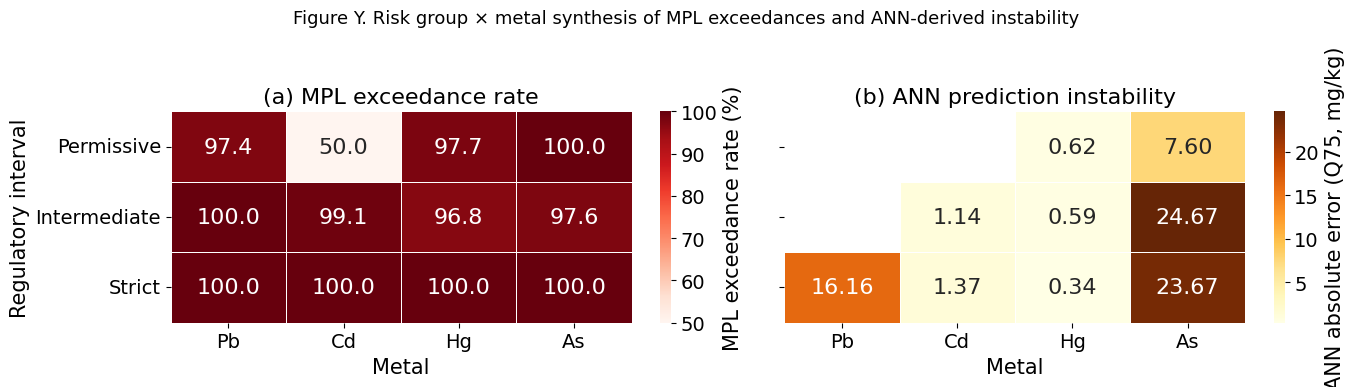

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

risk_map = {
    "Permissive regulatory categories": "Permissive",
    "Intermediate regulatory categories": "Intermediate",
    "Strict regulatory categories": "Strict"
}
risk_order = ["Permissive", "Intermediate", "Strict"]
metal_order = ["Pb", "Cd", "Hg", "As"]

ew = early_warning_final.copy()
ew["Risk_short"] = ew["Risk_Group_3"].map(risk_map)

hm_exceed = (ew.pivot(index="Risk_short", columns="Metal", values="exceed_rate_pct")
             .reindex(risk_order))
hm_ann = (ew.pivot(index="Risk_short", columns="Metal", values="q75_abs_error")
          .reindex(risk_order))

hm_exceed = hm_exceed.reindex(columns=[m for m in metal_order if m in hm_exceed.columns])
hm_ann = hm_ann.reindex(columns=[m for m in metal_order if m in hm_ann.columns])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

sns.heatmap(
    hm_exceed, annot=True, fmt=".1f",
    cmap="Reds", linewidths=0.5,
    mask=hm_exceed.isna(),
    cbar_kws={"label": "MPL exceedance rate (%)"},
    ax=axes[0]
)
axes[0].set_title("(a) MPL exceedance rate")
axes[0].set_xlabel("Metal")
axes[0].set_ylabel("Regulatory interval")

sns.heatmap(
    hm_ann, annot=True, fmt=".2f",
    cmap="YlOrBr", linewidths=0.5,
    mask=hm_ann.isna(),
    cbar_kws={"label": "ANN absolute error (Q75, mg/kg)"},
    ax=axes[1]
)
axes[1].set_title("(b) ANN prediction instability")
axes[1].set_xlabel("Metal")
axes[1].set_ylabel("")

plt.suptitle(
    "Figure Y. Risk group × metal synthesis of MPL exceedances and ANN-derived instability",
    fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# salvare MDPI
fig.savefig("/content/drive/MyDrive/heavy_metals/Figure_Y_heatmap_300dpi.tiff",
            dpi=300, format="tiff", bbox_inches="tight")

plt.show()


In [ ]:
mpl_summary = (
    df_exc
    .groupby(["Risk_Group_3", "Metal"])
    .agg(
        n_samples=("Conc", "count"),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean())
    )
    .reset_index()
)


In [ ]:
table5 = early_warning_final.copy()

# opțional: abrevieri pentru coloană, ca în figură
table5["Risk_Group"] = table5["Risk_Group_3"].map(risk_map)

# păstrăm doar ce trebuie pentru articol
table5 = table5[[
    "Risk_Group", "Metal", "n_records", "exceed_rate_pct",
    "n_ann", "q75_abs_error", "median_abs_error"
]].sort_values(["Risk_Group","Metal"])

table5.to_csv("/content/drive/MyDrive/heavy_metals/Table5_early_warning.csv", index=False)
table5.head(10)


,Risk_Group,Metal,n_records,exceed_rate_pct,n_ann,q75_abs_error,median_abs_error
0,Intermediate,As,41,97.560976,2.0,24.667825,16.878722
1,Intermediate,Cd,350,99.142857,49.0,1.137039,0.594795
2,Intermediate,Co,1,100.000000,NaN,NaN,NaN
3,Intermediate,Cr,1,100.000000,NaN,NaN,NaN
4,Intermediate,Cu,13,100.000000,NaN,NaN,NaN
5,Intermediate,Fe,1,100.000000,NaN,NaN,NaN
6,Intermediate,Hg,63,96.825397,63.0,0.590740,0.281962
7,Intermediate,Ni,3,100.000000,NaN,NaN,NaN
8,Intermediate,Pb,136,100.000000,NaN,NaN,NaN
9,Intermediate,Sb,2,100.000000,NaN,NaN,NaN


In [ ]:
mpl_summary = (
    df_exc
    .groupby(["Risk_Group_3", "Metal"])
    .agg(
        n_samples=("Conc", "count"),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean())
    )
    .reset_index()
)
ann_summary = (
    df_err
    .groupby(["Risk_Group_3", "Metal"])
    .agg(
        mean_abs_error=("Absolute_Error", "mean"),
        median_abs_error=("Absolute_Error", "median"),
        q75_abs_error=("Absolute_Error", lambda x: x.quantile(0.75))
    )
    .reset_index()
)
early_warning_final = mpl_summary.merge(
    ann_summary,
    on=["Risk_Group_3", "Metal"],
    how="left"
)
plot_early_warning = early_warning_final.copy()
plot_early_warning["Risk_short"] = plot_early_warning["Risk_Group_3"].map(risk_map)


In [ ]:
target_metals = ["Pb", "Cd", "Hg", "As"]


In [ ]:
t1_all = {
    "Total records (all metals)": len(df_exc),
    "Exceedance = 1": int(df_exc["Exceedance"].sum()),
    "Exceedance = 0": int((df_exc["Exceedance"] == 0).sum()),
}
t1_all["Exceedance prevalence (%)"] = 100 * t1_all["Exceedance = 1"] / t1_all["Total records (all metals)"]
t1_all


{'Total records (all metals)': 2986,
 'Exceedance = 1': 2910,
 'Exceedance = 0': 76,
 'Exceedance prevalence (%)': 97.45478901540523}

In [ ]:
df_exc4 = df_exc[df_exc["Metal"].isin(target_metals)].copy()

t1_4 = {
    "Total records (Pb/Cd/Hg/As)": len(df_exc4),
    "Exceedance = 1": int(df_exc4["Exceedance"].sum()),
    "Exceedance = 0": int((df_exc4["Exceedance"] == 0).sum()),
}
t1_4["Exceedance prevalence (%)"] = 100 * t1_4["Exceedance = 1"] / t1_4["Total records (Pb/Cd/Hg/As)"]
t1_4


{'Total records (Pb/Cd/Hg/As)': 2152,
 'Exceedance = 1': 2077,
 'Exceedance = 0': 75,
 'Exceedance prevalence (%)': 96.51486988847584}

In [ ]:
df_exc4 = df_exc[df_exc["Metal"].isin(target_metals)].copy()

t1_4 = {
    "Total records (Pb/Cd/Hg/As)": len(df_exc4),
    "Exceedance = 1": int(df_exc4["Exceedance"].sum()),
    "Exceedance = 0": int((df_exc4["Exceedance"] == 0).sum()),
}
t1_4["Exceedance prevalence (%)"] = 100 * t1_4["Exceedance = 1"] / t1_4["Total records (Pb/Cd/Hg/As)"]
t1_4


{'Total records (Pb/Cd/Hg/As)': 2152,
 'Exceedance = 1': 2077,
 'Exceedance = 0': 75,
 'Exceedance prevalence (%)': 96.51486988847584}

In [ ]:
import pandas as pd

t2 = pd.DataFrame([
    {"Metal": m,
     "MAE (mg/kg)": results[m]["mae"],
     "MSE (mg/kg²)": results[m]["mse"],
     "n_trainable": results[m].get("n_samples", None)
    }
    for m in target_metals if m in results
])

t2


,Metal,MAE (mg/kg),MSE (mg/kg²),n_trainable
0,Pb,11.958874,321.708649,372
1,Cd,1.080714,2.540287,570
2,Hg,0.443660,0.394748,1101
3,As,11.382230,299.190918,109


In [ ]:
df_err4 = df_err[df_err["Metal"].isin(target_metals)].copy()

t3 = (df_err4["Risk_Group_3"]
      .value_counts()
      .rename_axis("Risk_Group_3")
      .reset_index(name="n_ann_instances"))

t3["Share (%)"] = 100 * t3["n_ann_instances"] / t3["n_ann_instances"].sum()
t3


,Risk_Group_3,n_ann_instances,Share (%)
0,Strict regulatory categories,160,37.037037
1,Permissive regulatory categories,158,36.574074
2,Intermediate regulatory categories,114,26.388889


In [ ]:
t4 = (df_err4.groupby(["Metal","Risk_Group_3"])
      .size()
      .reset_index(name="n"))

t4_pivot = t4.pivot(index="Metal", columns="Risk_Group_3", values="n").fillna(0).astype(int)
t4_pivot


Risk_Group_3,Intermediate regulatory categories,Permissive regulatory categories,Strict regulatory categories
Metal,,,
As,2,7,13
Cd,49,0,65
Hg,63,151,7
Pb,0,0,75


In [ ]:
target_metals = ["Pb", "Cd", "Hg", "As"]

df_exc4 = df_exc[df_exc["Metal"].isin(target_metals)].copy()

table_S1 = (
    df_exc4
    .groupby(["Risk_Group_3", "Metal"])
    .agg(
        n_records=("Conc", "count"),
        exceed_n=("Exceedance", "sum"),
        non_exceed_n=("Exceedance", lambda x: (x==0).sum()),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean()),
        conc_median=("Conc", "median"),
        conc_q75=("Conc", lambda x: x.quantile(0.75)),
        mpl_median=("HM_limit_index", "median")
    )
    .reset_index()
)

# opțional: abrevieri pentru Risk_Group_3
risk_map = {
    "Permissive regulatory categories": "Permissive",
    "Intermediate regulatory categories": "Intermediate",
    "Strict regulatory categories": "Strict"
}
table_S1["Risk_Group"] = table_S1["Risk_Group_3"].map(risk_map)

# ordonare
metal_order = ["Pb","Cd","Hg","As"]
risk_order = ["Permissive","Intermediate","Strict"]

table_S1["Metal"] = pd.Categorical(table_S1["Metal"], categories=metal_order, ordered=True)
table_S1["Risk_Group"] = pd.Categorical(table_S1["Risk_Group"], categories=risk_order, ordered=True)

table_S1 = table_S1.sort_values(["Risk_Group","Metal"])

# select final (MDPI-friendly)
table_S1 = table_S1[[
    "Risk_Group", "Metal", "n_records",
    "exceed_n", "non_exceed_n", "exceed_rate_pct",
    "conc_median", "conc_q75", "mpl_median"
]]

table_S1.head(100)


,Risk_Group,Metal,n_records,exceed_n,non_exceed_n,exceed_rate_pct,conc_median,conc_q75,mpl_median
7,Permissive,Pb,39,38,1,97.435897,15.0000,27.5500,1.751839
5,Permissive,Cd,88,44,44,50.000000,0.4450,1.5250,0.402160
6,Permissive,Hg,1031,1007,24,97.672163,1.6000,2.0000,0.402160
4,Permissive,As,39,39,0,100.000000,7.4000,21.8500,1.751839
3,Intermediate,Pb,136,136,0,100.000000,5.2000,14.4500,0.041047
1,Intermediate,Cd,350,347,3,99.142857,1.5100,2.4000,0.207120
2,Intermediate,Hg,63,61,2,96.825397,0.5300,1.0100,0.115255
0,Intermediate,As,41,40,1,97.560976,7.3000,17.0000,0.041047
11,Strict,Pb,197,197,0,100.000000,10.3000,23.0300,0.000000
9,Strict,Cd,132,132,0,100.000000,0.8475,1.8075,0.000000


In [ ]:
import pandas as pd
import numpy as np

target_metals = ["Pb", "Cd", "Hg", "As"]

# subset strict pe metalele-țintă
df_exc4 = df_exc[df_exc["Metal"].isin(target_metals)].copy()

# mapare abrevieri pentru grupuri (opțional, păstrezi complet dacă vrei)
risk_map = {
    "Permissive regulatory categories": "Permissive regulatory categories",
    "Intermediate regulatory categories": "Intermediate regulatory categories",
    "Strict regulatory categories": "Strict regulatory categories"
}

df_exc4["Risk_Group_label"] = df_exc4["Risk_Group_3"].map(risk_map)

# agregare S1B
table_S1B = (
    df_exc4
    .groupby(["Risk_Group_label", "Metal", "Abbrev"], dropna=False)
    .agg(
        n_records=("Conc", "count"),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean()),
        conc_median=("Conc", "median"),
        conc_q75=("Conc", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

# (opțional) sortare: întâi grup, apoi metal, apoi cele mai multe înregistrări
group_order = [
    "Permissive regulatory categories",
    "Intermediate regulatory categories",
    "Strict regulatory categories"
]
metal_order = ["Pb", "Cd", "Hg", "As"]

table_S1B["Risk_Group_label"] = pd.Categorical(table_S1B["Risk_Group_label"], categories=group_order, ordered=True)
table_S1B["Metal"] = pd.Categorical(table_S1B["Metal"], categories=metal_order, ordered=True)

table_S1B = table_S1B.sort_values(
    ["Risk_Group_label", "Metal", "n_records"],
    ascending=[True, True, False]
)

# rotunjiri MDPI (ajustează dacă vrei mai multe zecimale)
table_S1B["exceed_rate_pct"] = table_S1B["exceed_rate_pct"].round(2)
table_S1B["conc_median"] = table_S1B["conc_median"].round(3)
table_S1B["conc_q75"] = table_S1B["conc_q75"].round(3)

# redenumire coloane (cap de tabel cu denumiri complete)
table_S1B = table_S1B.rename(columns={
    "Risk_Group_label": "Regulatory category interval",
    "Metal": "Heavy metal",
    "Abbrev": "Product category (abbrev.)",
    "n_records": "Number of records (n)",
    "exceed_rate_pct": "MPL exceedance rate (%)",
    "conc_median": "Median concentration (mg/kg)",
    "conc_q75": "75th percentile concentration (mg/kg)"
})

# select final exact în ordinea cerută
table_S1B = table_S1B[[
    "Regulatory category interval",
    "Heavy metal",
    "Product category (abbrev.)",
    "Number of records (n)",
    "MPL exceedance rate (%)",
    "Median concentration (mg/kg)",
    "75th percentile concentration (mg/kg)"
]]

table_S1B


,Regulatory category interval,Heavy metal,Product category (abbrev.),Number of records (n),MPL exceedance rate (%),Median concentration (mg/kg),75th percentile concentration (mg/kg)
38,Permissive regulatory categories,Pb,FM,19,94.74,21.000,33.045
35,Permissive regulatory categories,Pb,CF,6,100.00,18.600,22.208
37,Permissive regulatory categories,Pb,FFP,6,100.00,0.515,0.767
34,Permissive regulatory categories,Pb,CBp,5,100.00,0.470,0.490
36,Permissive regulatory categories,Pb,FA,3,100.00,67.500,68.000
28,Permissive regulatory categories,Cd,FFP,70,42.86,0.320,0.998
29,Permissive regulatory categories,Cd,FM,13,84.62,3.200,3.970
27,Permissive regulatory categories,Cd,CF,4,50.00,3.870,6.783
26,Permissive regulatory categories,Cd,CBp,1,100.00,0.150,0.150
32,Permissive regulatory categories,Hg,FFP,1008,99.70,1.600,2.000


In [ ]:
table_S1B.to_csv(
    "/content/drive/MyDrive/heavy_metals/Table_S1B_target_metals_by_category.csv",
    index=False
)


In [ ]:
table_S1b = (
    df_exc4
    .groupby(["Risk_Group_3", "Metal", "Abbrev"])
    .agg(
        n_records=("Conc", "count"),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean()),
        conc_median=("Conc", "median"),
        conc_q75=("Conc", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

table_S1b["Risk_Group"] = table_S1b["Risk_Group_3"].map(risk_map)

# sortare
table_S1b = table_S1b.sort_values(["Risk_Group","Metal","n_records"], ascending=[True, True, False])

table_S1b.head(50)


,Risk_Group_3,Metal,Abbrev,n_records,exceed_rate_pct,conc_median,conc_q75,Risk_Group
3,Intermediate regulatory categories,As,OFP,21,95.238095,7.10000,11.00000,Intermediate regulatory categories
1,Intermediate regulatory categories,As,DFFS,17,100.000000,9.90000,30.70000,Intermediate regulatory categories
0,Intermediate regulatory categories,As,BMs,2,100.000000,8.62550,12.81275,Intermediate regulatory categories
2,Intermediate regulatory categories,As,FV,1,100.000000,42.40000,42.40000,Intermediate regulatory categories
4,Intermediate regulatory categories,Cd,BMs,247,99.595142,1.80000,2.60000,Intermediate regulatory categories
7,Intermediate regulatory categories,Cd,FV,67,100.000000,0.30000,0.47500,Intermediate regulatory categories
8,Intermediate regulatory categories,Cd,MMPr,20,100.000000,0.36200,0.76250,Intermediate regulatory categories
5,Intermediate regulatory categories,Cd,CCPCf,8,100.000000,1.20605,1.70475,Intermediate regulatory categories
6,Intermediate regulatory categories,Cd,DFFS,5,60.000000,1.50000,1.88000,Intermediate regulatory categories
9,Intermediate regulatory categories,Cd,OFP,3,100.000000,1.58000,2.58000,Intermediate regulatory categories


In [ ]:
mpl_summary4 = (
    df_exc4
    .groupby(["Risk_Group_3","Metal"])
    .agg(
        n_records=("Conc","count"),
        exceed_rate_pct=("Exceedance", lambda x: 100*x.mean())
    )
    .reset_index()
)


In [ ]:
ann_summary4 = (
    df_err4
    .groupby(["Risk_Group_3","Metal"])
    .agg(
        n_ann=("Absolute_Error","count"),
        q75_abs_error=("Absolute_Error", lambda x: x.quantile(0.75)),
        median_abs_error=("Absolute_Error","median")
    )
    .reset_index()
)


In [ ]:
table5 = mpl_summary4.merge(ann_summary4, on=["Risk_Group_3","Metal"], how="left")

# opțional: scurtezi risk group pentru prezentare
risk_map = {
    "Permissive regulatory categories": "Permissive",
    "Intermediate regulatory categories": "Intermediate",
    "Strict regulatory categories": "Strict"
}
table5["Risk_Group"] = table5["Risk_Group_3"].map(risk_map)

table5 = table5[["Risk_Group","Metal","n_records","exceed_rate_pct","n_ann","q75_abs_error","median_abs_error"]] \
              .sort_values(["Risk_Group","Metal"])

# sanity check
print("Sum n_records =", table5["n_records"].sum(), " | len(df_exc4) =", len(df_exc4))

table5


Sum n_records = 2152  | len(df_exc4) = 2152


,Risk_Group,Metal,n_records,exceed_rate_pct,n_ann,q75_abs_error,median_abs_error
0,Intermediate,As,41,97.560976,2.0,24.667825,16.878722
1,Intermediate,Cd,350,99.142857,49.0,1.137039,0.594795
2,Intermediate,Hg,63,96.825397,63.0,0.590740,0.281962
3,Intermediate,Pb,136,100.000000,NaN,NaN,NaN
4,Permissive,As,39,100.000000,7.0,7.599867,3.924882
5,Permissive,Cd,88,50.000000,NaN,NaN,NaN
6,Permissive,Hg,1031,97.672163,151.0,0.619408,0.353299
7,Permissive,Pb,39,97.435897,NaN,NaN,NaN
8,Strict,As,29,100.000000,13.0,23.668629,5.075586
9,Strict,Cd,132,100.000000,65.0,1.368376,0.708987



0) Setari

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target_metals = ["Pb", "Cd", "Hg", "As"]

risk_map = {
    "Permissive regulatory categories": "Permissive",
    "Intermediate regulatory categories": "Intermediate",
    "Strict regulatory categories": "Strict"
}
risk_order = ["Permissive", "Intermediate", "Strict"]
metal_order = ["Pb", "Cd", "Hg", "As"]


1) Refacere df_exc (CURAT) din df_clean

In [ ]:
# asigurăm numeric
df_clean["Rank_Category"] = pd.to_numeric(df_clean["Rank_Category"], errors="coerce")
df_clean["Conc"] = pd.to_numeric(df_clean["Conc"], errors="coerce")
df_clean["HM_limit_index"] = pd.to_numeric(df_clean["HM_limit_index"], errors="coerce")

def risk_group_3(rank):
    if pd.isna(rank):
        return np.nan
    r = int(rank)
    if r <= 4:
        return "Permissive regulatory categories"
    elif r <= 10:
        return "Intermediate regulatory categories"
    else:
        return "Strict regulatory categories"

df_exc = df_clean.copy()
df_exc["Risk_Group_3"] = df_exc["Rank_Category"].apply(risk_group_3)

# depășire MPL
df_exc["Exceedance"] = (df_exc["Conc"] > df_exc["HM_limit_index"]).astype(int)

print("df_clean:", df_clean.shape)
print("df_exc:", df_exc.shape)
print(df_exc["Exceedance"].value_counts())
print(df_exc["Risk_Group_3"].value_counts(dropna=False))


df_clean: (2986, 15)
df_exc: (2986, 16)
Exceedance
1    2910
0      76
Name: count, dtype: int64
Risk_Group_3
Permissive regulatory categories      1214
Strict regulatory categories          1112
Intermediate regulatory categories     660
Name: count, dtype: int64


In [ ]:
df_exc4 = df_exc[df_exc["Metal"].isin(target_metals)].copy()
df_err4 = df_err[df_err["Metal"].isin(target_metals)].copy()

print("df_exc4:", df_exc4.shape)
print("df_err4:", df_err4.shape)


df_exc4: (2152, 16)
df_err4: (432, 5)


In [ ]:
# A) MPL exceedance (notification-level)
mpl_summary4 = (
    df_exc4
    .groupby(["Risk_Group_3", "Metal"])
    .agg(
        n_records=("Conc", "count"),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean())
    )
    .reset_index()
)

# B) ANN instability (error-level)
ann_summary4 = (
    df_err4
    .groupby(["Risk_Group_3", "Metal"])
    .agg(
        n_ann=("Absolute_Error", "count"),
        q75_abs_error=("Absolute_Error", lambda x: x.quantile(0.75)),
        median_abs_error=("Absolute_Error", "median")
    )
    .reset_index()
)

# C) merge safe (agregat)
table5 = mpl_summary4.merge(ann_summary4, on=["Risk_Group_3", "Metal"], how="left")

# scurtăm labelul pentru afișare
table5["Risk_Group"] = table5["Risk_Group_3"].map(risk_map)

# ordonare
table5["Risk_Group"] = pd.Categorical(table5["Risk_Group"], categories=risk_order, ordered=True)
table5["Metal"] = pd.Categorical(table5["Metal"], categories=metal_order, ordered=True)

table5 = table5.sort_values(["Risk_Group", "Metal"])

# rotunjiri
table5["exceed_rate_pct"] = table5["exceed_rate_pct"].round(2)
table5["q75_abs_error"] = table5["q75_abs_error"].round(3)
table5["median_abs_error"] = table5["median_abs_error"].round(3)

table5 = table5[["Risk_Group", "Metal", "n_records", "exceed_rate_pct", "n_ann", "q75_abs_error", "median_abs_error"]]

table5_out = table5[[
    "Risk_Group",
    "Metal",
    "n_records",
    "exceed_rate_pct",
    "n_ann",
    "q75_abs_error",
    "median_abs_error"
]].copy()

table5_out = table5_out.rename(columns={
    "Risk_Group": "Regulatory category interval",
    "Metal": "Heavy metal",
    "n_records": "Number of records (n)",
    "exceed_rate_pct": "MPL exceedance rate (%)",
    "n_ann": "Number of ANN error instances (n)",
    "q75_abs_error": "ANN absolute error (Q75, mg/kg)",
    "median_abs_error": "ANN absolute error (median, mg/kg)"
})

print("Sanity check: sum(n_records) =", table5["n_records"].sum(), "| len(df_exc4) =", len(df_exc4))
table5_out


Sanity check: sum(n_records) = 2152 | len(df_exc4) = 2152


,Regulatory category interval,Heavy metal,Number of records (n),MPL exceedance rate (%),Number of ANN error instances (n),"ANN absolute error (Q75, mg/kg)","ANN absolute error (median, mg/kg)"
7,Permissive,Pb,39,97.44,NaN,NaN,NaN
5,Permissive,Cd,88,50.00,NaN,NaN,NaN
6,Permissive,Hg,1031,97.67,151.0,0.619,0.353
4,Permissive,As,39,100.00,7.0,7.600,3.925
3,Intermediate,Pb,136,100.00,NaN,NaN,NaN
1,Intermediate,Cd,350,99.14,49.0,1.137,0.595
2,Intermediate,Hg,63,96.83,63.0,0.591,0.282
0,Intermediate,As,41,97.56,2.0,24.668,16.879
11,Strict,Pb,197,100.00,75.0,16.164,8.366
9,Strict,Cd,132,100.00,65.0,1.368,0.709


In [ ]:
table_S1B = (
    df_exc4
    .groupby(["Risk_Group_3", "Metal", "Abbrev"])
    .agg(
        n_records=("Conc", "count"),
        exceed_rate_pct=("Exceedance", lambda x: 100 * x.mean()),
        conc_median=("Conc", "median"),
        conc_q75=("Conc", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

table_S1B["Risk_Group"] = table_S1B["Risk_Group_3"].map(risk_map)

table_S1B["Risk_Group"] = pd.Categorical(table_S1B["Risk_Group"], categories=risk_order, ordered=True)
table_S1B["Metal"] = pd.Categorical(table_S1B["Metal"], categories=metal_order, ordered=True)

table_S1B = table_S1B.sort_values(["Risk_Group", "Metal", "n_records"], ascending=[True, True, False])

# rotunjiri
table_S1B["exceed_rate_pct"] = table_S1B["exceed_rate_pct"].round(2)
table_S1B["conc_median"] = table_S1B["conc_median"].round(3)
table_S1B["conc_q75"] = table_S1B["conc_q75"].round(3)

table_S1B = table_S1B[["Risk_Group", "Metal", "Abbrev", "n_records", "exceed_rate_pct", "conc_median", "conc_q75"]]

table_S1B


,Risk_Group,Metal,Abbrev,n_records,exceed_rate_pct,conc_median,conc_q75
38,Permissive,Pb,FM,19,94.74,21.000,33.045
35,Permissive,Pb,CF,6,100.00,18.600,22.208
37,Permissive,Pb,FFP,6,100.00,0.515,0.767
34,Permissive,Pb,CBp,5,100.00,0.470,0.490
36,Permissive,Pb,FA,3,100.00,67.500,68.000
28,Permissive,Cd,FFP,70,42.86,0.320,0.998
29,Permissive,Cd,FM,13,84.62,3.200,3.970
27,Permissive,Cd,CF,4,50.00,3.870,6.783
26,Permissive,Cd,CBp,1,100.00,0.150,0.150
32,Permissive,Hg,FFP,1008,99.70,1.600,2.000


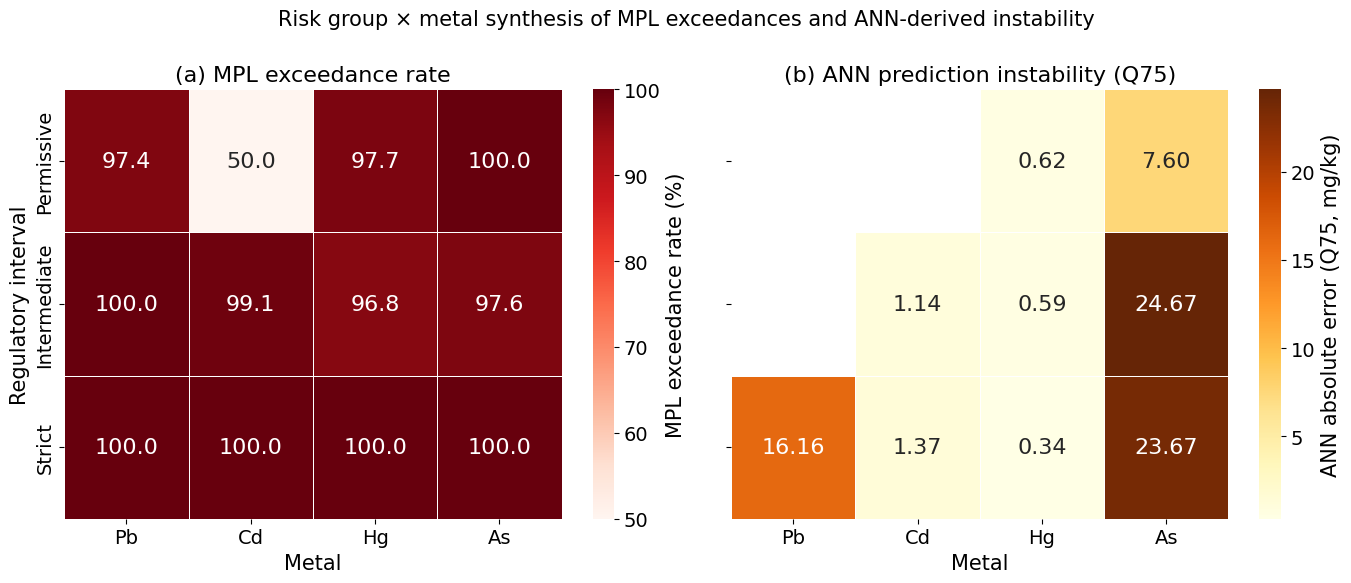

In [ ]:
# pivot pentru heatmap
hm_exceed = (table5.pivot(index="Risk_Group", columns="Metal", values="exceed_rate_pct")
             .reindex(risk_order)[metal_order])

hm_ann = (table5.pivot(index="Risk_Group", columns="Metal", values="q75_abs_error")
          .reindex(risk_order)[metal_order])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.heatmap(
    hm_exceed, annot=True, fmt=".1f",
    cmap="Reds", linewidths=0.5,
    mask=hm_exceed.isna(),
    cbar_kws={"label": "MPL exceedance rate (%)"},
    ax=axes[0]
)
axes[0].set_title("(a) MPL exceedance rate")
axes[0].set_xlabel("Metal")
axes[0].set_ylabel("Regulatory interval")

sns.heatmap(
    hm_ann, annot=True, fmt=".2f",
    cmap="YlOrBr", linewidths=0.5,
    mask=hm_ann.isna(),
    cbar_kws={"label": "ANN absolute error (Q75, mg/kg)"},
    ax=axes[1]
)
axes[1].set_title("(b) ANN prediction instability (Q75)")
axes[1].set_xlabel("Metal")
axes[1].set_ylabel("")

plt.suptitle(
    "Risk group × metal synthesis of MPL exceedances and ANN-derived instability",
    fontsize=15
)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

# salvare MDPI
fig.savefig("/content/drive/MyDrive/heavy_metals/Figure_Y_300dpi3.tiff",
            dpi=300, format="tiff", bbox_inches="tight")


In [ ]:
metale_toxice = ["Pb", "Cd", "Hg", "As"]
df_ml = df_clean[df_clean["Metal"].isin(metale_toxice)].copy()

# target (dacă ai nevoie de binar la alt pas)
df_ml["Risk"] = df_ml["Risk_decision"].map({"serious":1, "not serious":0})

numeric_features = ["Conc", "Rank_Category"]
categorical_features = ["Metal", "Product_category", "Notified_by", "Origin"]

# IMPORTANT: drop_first=False ca să păstrezi și Metal_As
df_ml_encoded = pd.get_dummies(
    df_ml[numeric_features + categorical_features + ["Risk"]],
    drop_first=False
)

df_ml_encoded.filter(like="Metal_").head()


,Metal_As,Metal_Cd,Metal_Hg,Metal_Pb
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False


In [ ]:
metal_cols = ["Metal_As", "Metal_Cd", "Metal_Hg", "Metal_Pb"]
df_ml_encoded["metal_onehot_sum"] = df_ml_encoded[metal_cols].sum(axis=1)
df_ml_encoded["metal_onehot_sum"].value_counts()




,count
metal_onehot_sum,
1,2152


In [ ]:
metal_code = "Hg"   # sau "As", "Cd", "Pb"
df_m = df_ml_encoded[df_ml_encoded[f"Metal_{metal_code}"] == True].copy()
df_m.head()


,Conc,Rank_Category,Risk,Metal_As,Metal_Cd,Metal_Hg,Metal_Pb,"Product_category_bivalve molluscs, cephalopods and products thereof",Product_category_cereals and bakery products,"Product_category_cocoa and cocoa preparations, coffee and tea",...,Origin_Ukraine,Origin_United Arab Emirates,Origin_United Kingdom,Origin_United States,Origin_Unknown,Origin_Uruguay,Origin_Uzbekistan,Origin_Vietnam,Origin_Yemen,metal_onehot_sum
679,0.383,1.0,NaN,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
680,0.900,2.0,NaN,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
681,1.140,2.0,0.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
682,0.750,2.0,NaN,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
683,0.750,2.0,1.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1


In [ ]:
print("type(results) =", type(results))

if isinstance(results, dict):
    print("keys(results) =", list(results.keys())[:20])
else:
    # dacă e DataFrame sau altceva, vezi primele rânduri
    try:
        display(results.head())
    except Exception as e:
        print("Nu pot face head():", e)


type(results) = <class 'dict'>
keys(results) = []


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

target_metals = ["Pb", "Cd", "Hg", "As"]
metal_cols = [f"Metal_{m}" for m in target_metals]

def train_ann_for_metal_store(df_ml_encoded, metal_code, random_state=42, epochs=50, batch_size=32):
    # 1) selectăm rândurile metalului curent (one-hot)
    df_m = df_ml_encoded[df_ml_encoded[f"Metal_{metal_code}"] == True].copy()

    # 2) trebuie să existe Conc
    df_m = df_m.dropna(subset=["Conc"]).copy()

    # 3) y și X (scoatem Risk + Metal_* ca să nu fie feature constant)
    y = df_m["Conc"].astype(float).values
    X = df_m.drop(columns=["Conc", "Risk"] + metal_cols, errors="ignore")
    feature_names = X.columns.tolist()

    # 4) split
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y, test_size=0.20, random_state=random_state
    )

    # 5) scalare
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 6) model
    model = models.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    # 7) predict + metrici
    y_pred = model.predict(X_test_scaled, verbose=0).flatten()
    mae = float(np.mean(np.abs(y_test - y_pred)))
    mse = float(np.mean((y_test - y_pred) ** 2))

    return {
        "metal": metal_code,
        "model": model,
        "history": history.history,
        "mae": mae,
        "mse": mse,
        "scaler": scaler,
        "feature_names": feature_names,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "n_samples": int(len(df_m))
    }

# ---------------------------
# Reconstruim results complet
# ---------------------------
results = {}
for m in target_metals:
    results[m] = train_ann_for_metal_store(df_ml_encoded, m)

print("keys(results) =", list(results.keys()))
[(m, results[m]["mae"], results[m]["mse"], results[m]["n_samples"]) for m in target_metals]


keys(results) = ['Pb', 'Cd', 'Hg', 'As']


[('Pb', 12.10573509370168, 318.05235863234475, 372),
 ('Cd', 1.012511883539066, 2.3122204684907706, 570),
 ('Hg', 0.43937332059118, 0.37626108818269977, 1101),
 ('As', 11.078404157465155, 288.4098977822036, 109)]

In [ ]:
import pandas as pd
import shap
import numpy as np

def feature_group(name):
    if name.startswith("Origin_"):
        return "Origin"
    if name.startswith("Product_category_"):
        return "Product category"
    if name.startswith("Notified_by_"):
        return "Notified by"
    if name == "Rank_Category":
        return "Regulatory rank"
    return "Other"

def run_shap_and_summarize(results, metal, background_size=150, explain_size=80, nsamples=120):
    model = results[metal]["model"]
    Xtr = results[metal]["X_train_scaled"]
    Xte = results[metal]["X_test_scaled"]
    feat = results[metal]["feature_names"]

    bg = shap.sample(Xtr, min(background_size, Xtr.shape[0]), random_state=42)
    Xexp = Xte[:min(explain_size, Xte.shape[0])]

    f = lambda x: model.predict(x, verbose=0).flatten()
    explainer = shap.KernelExplainer(f, bg)
    shap_values = explainer.shap_values(Xexp, nsamples=nsamples)

    mean_abs = np.mean(np.abs(shap_values), axis=0)
    df_feat = pd.DataFrame({"Feature": feat, "MeanAbsSHAP": mean_abs})
    df_feat["Group"] = df_feat["Feature"].apply(feature_group)

    grp_sum = df_feat.groupby("Group")["MeanAbsSHAP"].sum()
    total = grp_sum.sum()
    grp_pct = (100 * grp_sum / total).to_dict()

    top5 = df_feat.sort_values("MeanAbsSHAP", ascending=False).head(5)

    row = {
        "Metal": metal,
        "MAE": results[metal]["mae"],
        "MSE": results[metal]["mse"],
        "Origin_%": float(grp_pct.get("Origin", 0)),
        "Product_category_%": float(grp_pct.get("Product category", 0)),
        "Notified_by_%": float(grp_pct.get("Notified by", 0)),
        "Rank_Category_%": float(grp_pct.get("Regulatory rank", 0)),
        "Top5_features": "; ".join(top5["Feature"].tolist())
    }
    return row

rows = []
for m in ["Pb","Cd","Hg","As"]:
    rows.append(run_shap_and_summarize(results, m))

shap_metrics = pd.DataFrame(rows)
shap_metrics


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

,Metal,MAE,MSE,Origin_%,Product_category_%,Notified_by_%,Rank_Category_%,Top5_features
0,Pb,12.105735,318.052359,26.790813,43.825854,22.917096,6.466236,Product_category_feed materials; Product_categ...
1,Cd,1.012512,2.312220,36.144818,35.166620,24.845634,3.842928,"Product_category_bivalve molluscs, cephalopods..."
2,Hg,0.439373,0.376261,62.341130,12.599225,23.733783,1.325862,Origin_Spain; Notified_by_Italy; Origin_France...
3,As,11.078404,288.409898,66.230161,20.094982,11.328322,2.346535,Origin_France; Origin_Netherlands; Origin_Chin...


In [ ]:
!pip -q install shap

import shap
import numpy as np
import pandas as pd

def feature_group(name):
    if name.startswith("Origin_"):
        return "Origin"
    if name.startswith("Product_category_"):
        return "Product category"
    if name.startswith("Notified_by_"):
        return "Notified by"
    if name == "Rank_Category":
        return "Regulatory rank (Rank_Category)"
    return "Other"

def run_shap(results, metal, background_size=120, explain_size=60, nsamples=120):
    model = results[metal]["model"]
    Xtr = results[metal]["X_train_scaled"]
    Xte = results[metal]["X_test_scaled"]
    feat = results[metal]["feature_names"]

    bg = shap.sample(Xtr, min(background_size, Xtr.shape[0]), random_state=42)
    Xexp = Xte[:min(explain_size, Xte.shape[0])]

    f = lambda x: model.predict(x, verbose=0).flatten()
    explainer = shap.KernelExplainer(f, bg)
    shap_values = explainer.shap_values(Xexp, nsamples=nsamples)

    mean_abs = np.mean(np.abs(shap_values), axis=0)
    df_feat = pd.DataFrame({"Feature": feat, "MeanAbsSHAP": mean_abs})
    df_feat["Group"] = df_feat["Feature"].apply(feature_group)

    # group %
    grp_sum = df_feat.groupby("Group")["MeanAbsSHAP"].sum()
    total = grp_sum.sum()
    grp_pct = (100 * grp_sum / total).to_dict()

    # top features
    top5 = (df_feat.sort_values("MeanAbsSHAP", ascending=False)
                 .head(5)
                 .assign(Metal=metal))

    row = {
        "Metal": metal,
        "n_samples": results[metal]["n_samples"],
        "MAE (mg/kg)": results[metal]["mae"],
        "MSE (mg/kg^2)": results[metal]["mse"],
        "Origin_SHAP_%": float(grp_pct.get("Origin", 0.0)),
        "ProductCat_SHAP_%": float(grp_pct.get("Product category", 0.0)),
        "NotifiedBy_SHAP_%": float(grp_pct.get("Notified by", 0.0)),
        "RankCategory_SHAP_%": float(grp_pct.get("Regulatory rank (Rank_Category)", 0.0)),
        "Other_SHAP_%": float(grp_pct.get("Other", 0.0)),
    }
    return row, top5, df_feat

target_metals = ["Pb","Cd","Hg","As"]

rows = []
top_list = []
feat_list = []

for m in target_metals:
    r, top5, df_feat = run_shap(results, m, background_size=120, explain_size=60, nsamples=120)
    rows.append(r)
    top_list.append(top5)
    feat_list.append(df_feat.assign(Metal=m))

shap_metrics = pd.DataFrame(rows)
shap_top5 = pd.concat(top_list, ignore_index=True)

# rotunjiri pentru tabel MDPI
shap_metrics_mdpi = shap_metrics.copy()
for c in ["MAE (mg/kg)","MSE (mg/kg^2)","Origin_SHAP_%","ProductCat_SHAP_%","NotifiedBy_SHAP_%","RankCategory_SHAP_%","Other_SHAP_%"]:
    shap_metrics_mdpi[c] = shap_metrics_mdpi[c].round(3)

shap_metrics_mdpi, shap_top5


  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

(  Metal  n_samples  MAE (mg/kg)  MSE (mg/kg^2)  Origin_SHAP_%  \
 0    Pb        372       12.106        318.052         24.786   
 1    Cd        570        1.013          2.312         35.258   
 2    Hg       1101        0.439          0.376         63.912   
 3    As        109       11.078        288.410         65.063   
 
    ProductCat_SHAP_%  NotifiedBy_SHAP_%  RankCategory_SHAP_%  Other_SHAP_%  
 0             47.613             20.779                6.822           0.0  
 1             34.436             26.165                4.141           0.0  
 2             11.754             23.495                0.839           0.0  
 3             21.156             11.778                2.003           0.0  ,
                                               Feature  MeanAbsSHAP  \
 0                     Product_category_feed materials     1.758262   
 1              Product_category_fruits and vegetables     1.109864   
 2                                 Notified_by_Germany     0.844

In [ ]:
def short_text(m, shap_metrics_df, top_df):
    r = shap_metrics_df[shap_metrics_df["Metal"] == m].iloc[0]
    top = top_df[top_df["Metal"] == m].sort_values("MeanAbsSHAP", ascending=False)["Feature"].tolist()
    top3 = ", ".join(top[:3])

    return (f"{m}: ANN performance (MAE={r['MAE (mg/kg)']:.3f} mg/kg; MSE={r['MSE (mg/kg^2)']:.3f} mg/kg²; "
            f"n={int(r['n_samples'])}) indicates "
            f"{'high' if r['MAE (mg/kg)']<1 else ('moderate' if r['MAE (mg/kg)']<3 else 'low')} predictability. "
            f"SHAP attribution was dominated by Origin ({r['Origin_SHAP_%']:.1f}%) and Product category ({r['ProductCat_SHAP_%']:.1f}%), "
            f"with key drivers including: {top3}.")

for m in ["Hg","Cd","Pb","As"]:
    print(short_text(m, shap_metrics_mdpi, shap_top5))
    print()


Hg: ANN performance (MAE=0.439 mg/kg; MSE=0.376 mg/kg²; n=1101) indicates high predictability. SHAP attribution was dominated by Origin (63.9%) and Product category (11.8%), with key drivers including: Origin_Spain, Notified_by_Italy, Product_category_dietetic foods, food supplements, fortified foods.

Cd: ANN performance (MAE=1.013 mg/kg; MSE=2.312 mg/kg²; n=570) indicates moderate predictability. SHAP attribution was dominated by Origin (35.3%) and Product category (34.4%), with key drivers including: Product_category_bivalve molluscs, cephalopods and products thereof, Product_category_fish and fish products, Product_category_crustaceans and products thereof.

Pb: ANN performance (MAE=12.106 mg/kg; MSE=318.052 mg/kg²; n=372) indicates low predictability. SHAP attribution was dominated by Origin (24.8%) and Product category (47.6%), with key drivers including: Product_category_feed materials, Product_category_fruits and vegetables, Notified_by_Germany.

As: ANN performance (MAE=11.078

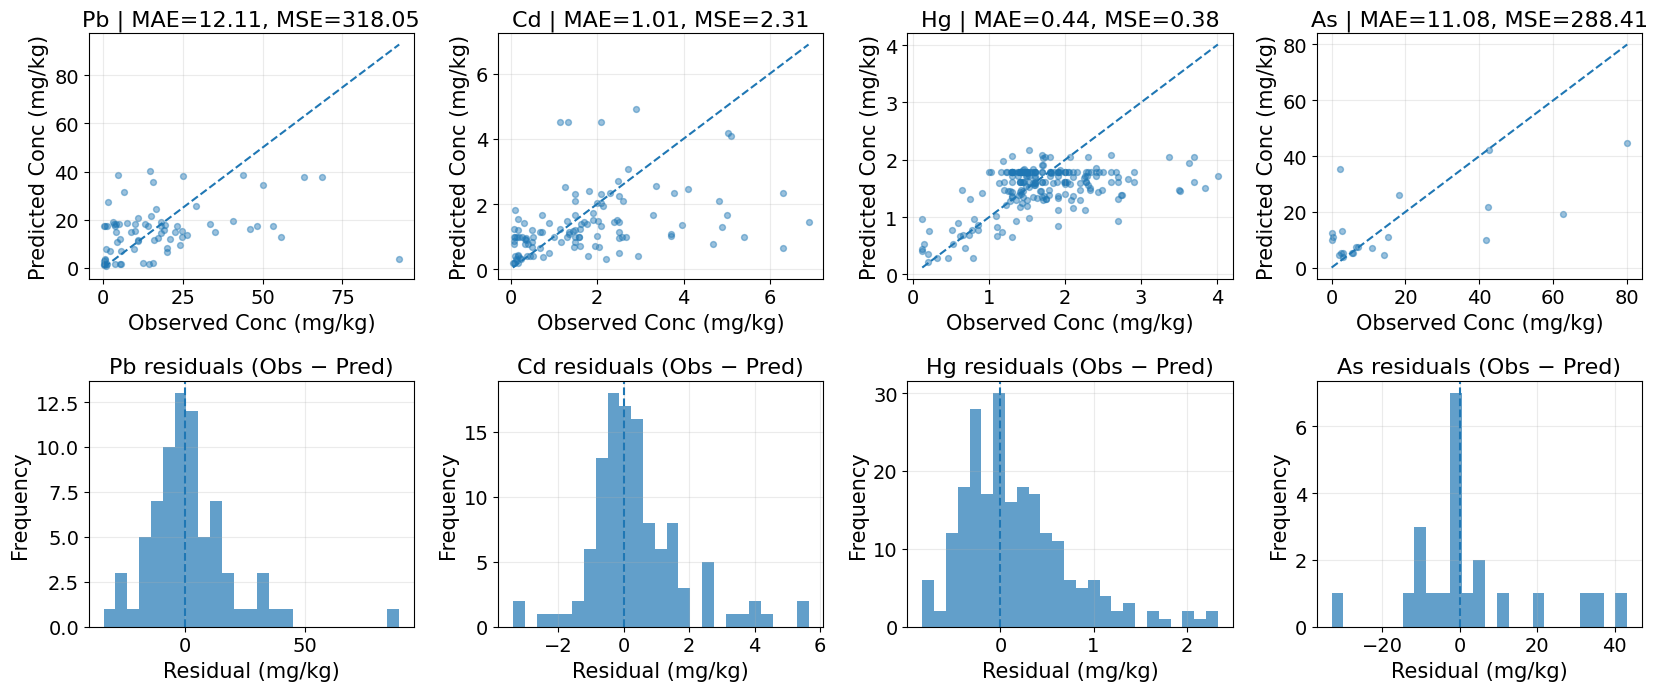

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metals = ["Pb", "Cd", "Hg", "As"]

def plot_ann_diagnostics_grid(results, metals, y_max_clip=None):
    """
    2 x N:
      Row 1: Actual vs Predicted
      Row 2: Residual histogram
    y_max_clip: dacă vrei să tai outlierii (ex. 99th percentile) ca să se vadă densitatea.
    """
    n = len(metals)
    fig, axes = plt.subplots(2, n, figsize=(4.2*n, 7.2))

    for j, m in enumerate(metals):
        y_true = np.array(results[m]["y_test"])
        y_pred = np.array(results[m]["y_pred"])
        resid  = y_true - y_pred

        # opțional clip pentru vizibilitate (nu afectează calculele, doar plot)
        if y_max_clip is not None:
            cap = np.quantile(np.concatenate([y_true, y_pred]), y_max_clip)
            y_true_p = np.clip(y_true, None, cap)
            y_pred_p = np.clip(y_pred, None, cap)
        else:
            y_true_p, y_pred_p = y_true, y_pred

        # ---------------- Row 1: scatter ----------------
        ax = axes[0, j]
        ax.scatter(y_true_p, y_pred_p, alpha=0.45, s=18)
        lo = min(y_true_p.min(), y_pred_p.min())
        hi = max(y_true_p.max(), y_pred_p.max())
        ax.plot([lo, hi], [lo, hi], linestyle="--")
        ax.set_title(f"{m} | MAE={results[m]['mae']:.2f}, MSE={results[m]['mse']:.2f}")
        ax.set_xlabel("Observed Conc (mg/kg)")
        ax.set_ylabel("Predicted Conc (mg/kg)")
        ax.grid(alpha=0.25)

        # ---------------- Row 2: residual hist ----------------
        ax2 = axes[1, j]
        ax2.hist(resid, bins=25, alpha=0.7)
        ax2.axvline(0, linestyle="--")
        ax2.set_title(f"{m} residuals (Obs − Pred)")
        ax2.set_xlabel("Residual (mg/kg)")
        ax2.set_ylabel("Frequency")
        ax2.grid(alpha=0.25)

    plt.tight_layout()
    return fig

figA = plot_ann_diagnostics_grid(results, metals, y_max_clip=None)  # sau 0.99 dacă Pb/As îți “strică” scara
plt.show()

# Salvare MDPI (TIFF 300 dpi)
figA.savefig("/content/drive/MyDrive/heavy_metals/Figure_ANN_Diagnostics_2x4.tiff",
             dpi=300, format="tiff")


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

target_metals = ["Pb", "Cd", "Hg", "As"]

def shap_summary_for_metal_top10(
    results,
    metal_code,
    bg_n=150,
    exp_n=80,
    nsamples=150,
    max_display=10,
    out_prefix="/content/drive/MyDrive/heavy_metals"
):
    model = results[metal_code]["model"]
    Xtr = results[metal_code]["X_train_scaled"]
    Xte = results[metal_code]["X_test_scaled"]
    feat = results[metal_code]["feature_names"]

    bg = shap.sample(Xtr, min(bg_n, Xtr.shape[0]), random_state=42)
    Xexp = Xte[:min(exp_n, Xte.shape[0])]

    f = lambda x: model.predict(x, verbose=0).flatten()
    explainer = shap.KernelExplainer(f, bg)
    shap_values = explainer.shap_values(Xexp, nsamples=nsamples)

    # ---------------- Beeswarm (Top 10) ----------------
    plt.figure(figsize=(9, 5.5))
    shap.summary_plot(
        shap_values, Xexp,
        feature_names=feat,
        show=False,
        max_display=max_display
    )
    plt.title(f"SHAP summary (beeswarm, Top {max_display}) — {metal_code}")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}/SHAP_beeswarm_top{max_display}_{metal_code}.tiff",
                dpi=300, format="tiff")
    plt.savefig(f"{out_prefix}/SHAP_beeswarm_top{max_display}_{metal_code}.png",
                dpi=300)
    plt.close()

    # ---------------- Bar (Top 10) ----------------
    plt.figure(figsize=(9, 5.5))
    shap.summary_plot(
        shap_values, Xexp,
        feature_names=feat,
        plot_type="bar",
        show=False,
        max_display=max_display
    )
    plt.title(f"SHAP summary (bar, Top {max_display}) — {metal_code}")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}/SHAP_bar_top{max_display}_{metal_code}.tiff",
                dpi=300, format="tiff")
    plt.savefig(f"{out_prefix}/SHAP_bar_top{max_display}_{metal_code}.png",
                dpi=300)
    plt.close()

    return shap_values, Xexp, feat

# Rulează pentru toate 4
shap_store = {}
for m in target_metals:
    sv, Xexp, feat = shap_summary_for_metal_top10(
        results, m,
        bg_n=150, exp_n=80, nsamples=150,
        max_display=10
    )
    shap_store[m] = {"shap_values": sv, "Xexp": Xexp, "feat": feat}

print("Saved Top-10 SHAP plots for:", list(shap_store.keys()))


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

Saved Top-10 SHAP plots for: ['Pb', 'Cd', 'Hg', 'As']


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
import shap

# =========================
# FONT MAP (centralizat)
# =========================
FONTS = {
    "title": 14,
    "subtitle": 12,
    "label": 12,
    "tick": 10,
    "legend": 10
}

plt.rcParams.update({
    "axes.titlesize": FONTS["title"],
    "axes.labelsize": FONTS["label"],
    "xtick.labelsize": FONTS["tick"],
    "ytick.labelsize": FONTS["tick"],
    "legend.fontsize": FONTS["legend"],
})

# =========================
# Abrevieri pentru Product_category_ (custom)
# Completează/editează după lista ta reală
# =========================
CAT_ABBR = {
    "feed materials": "FM",
    "feed additives": "FA",
    "cereals and bakery products": "CF",
    "food for infants and young children": "FFP",
    "dietetic foods, food supplements": "DFFS",
    "bivalve molluscs, cephalopods and products thereof": "BMs",
    "fruits and vegetables": "FV",
    "cocoa and cocoa preparations, coffee and tea": "CBp",
    "food contact materials": "FCM",
    "herbs and spices": "HSp",
    "meat and meat products": "MMPr",
    "processed meat products": "PMPMP",
    "other food products / other": "OFP"
}

def shorten_text(s, maxlen=18):
    s = str(s)
    s = re.sub(r"\s+", "_", s.strip())
    return s if len(s) <= maxlen else (s[:maxlen-1] + "…")

def abbreviate_feature(name):
    # exact numeric feature
    if name == "Rank_Category":
        return "RankCat"

    # one-hot prefixes
    if name.startswith("Origin_"):
        val = name.replace("Origin_", "")
        return "Org:" + shorten_text(val, 14)

    if name.startswith("Notified_by_"):
        val = name.replace("Notified_by_", "")
        return "Notif:" + shorten_text(val, 12)

    if name.startswith("Product_category_"):
        val = name.replace("Product_category_", "").strip()
        if val in CAT_ABBR:
            return "Cat:" + CAT_ABBR[val]
        return "Cat:" + shorten_text(val, 14)

    # fallback
    return shorten_text(name, 18)


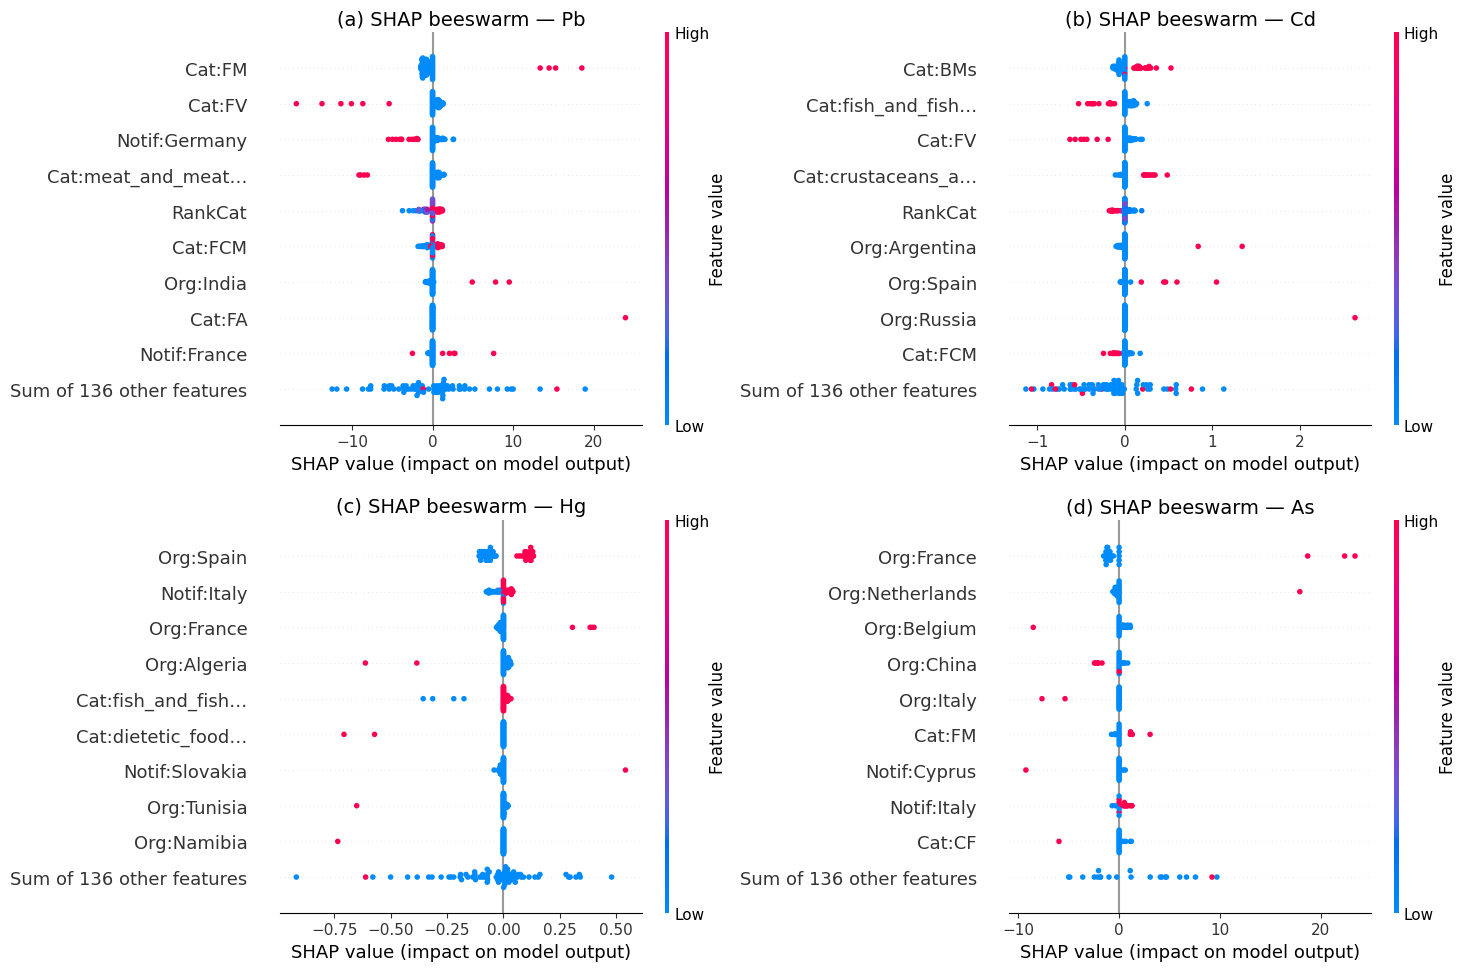

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

metals = ["Pb", "Cd", "Hg", "As"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, m in enumerate(metals):
    sv = shap_store[m]["shap_values"]
    Xexp = shap_store[m]["Xexp"]
    feat = shap_store[m]["feat"]

    feat_short = [abbreviate_feature(f) for f in feat]

    expl = shap.Explanation(
        values=sv,
        data=Xexp,
        feature_names=feat_short
    )

    # IMPORTANT: plot_size=None ca să funcționeze ax=...
    shap.plots.beeswarm(
        expl,
        max_display=10,
        show=False,
        ax=axes[i],
        plot_size=None
    )
    axes[i].set_title(f"({chr(97+i)}) SHAP beeswarm — {m}")

plt.tight_layout()
plt.show()

fig.savefig("/content/drive/MyDrive/heavy_metals/Figure6_SHAP_beeswarm_top10_2x2_abbrev.tiff",
            dpi=300, format="tiff")


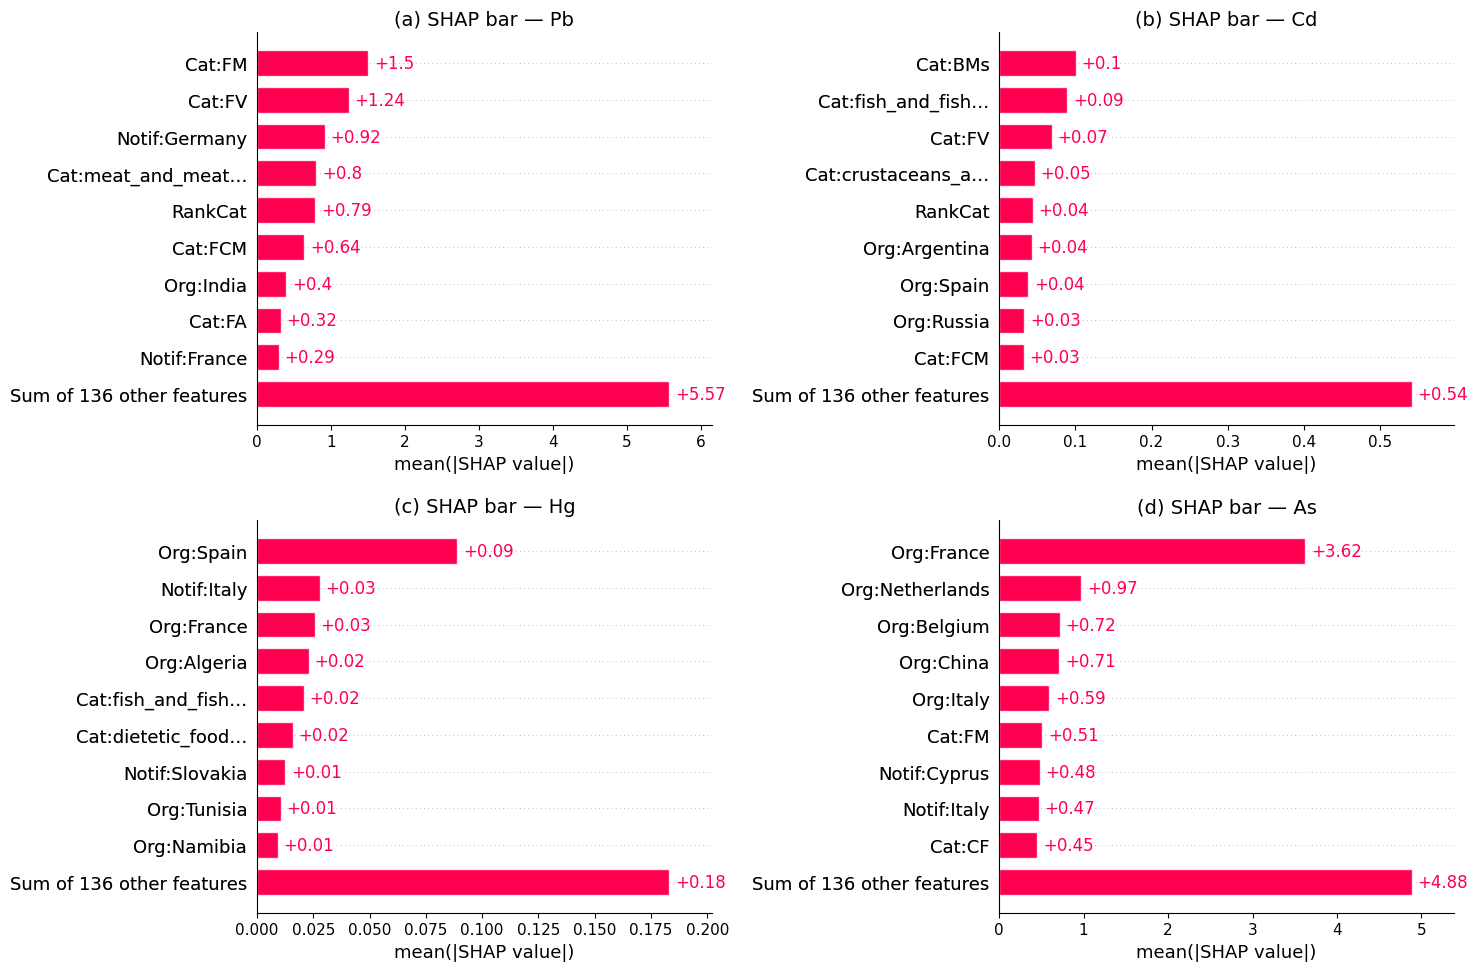

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, m in enumerate(metals):
    sv = shap_store[m]["shap_values"]
    Xexp = shap_store[m]["Xexp"]
    feat = shap_store[m]["feat"]

    feat_short = [abbreviate_feature(f) for f in feat]

    expl = shap.Explanation(
        values=sv,
        data=Xexp,
        feature_names=feat_short
    )

    shap.plots.bar(
        expl,
        max_display=10,
        show=False,
        ax=axes[i]
    )
    axes[i].set_title(f"({chr(97+i)}) SHAP bar — {m}")

plt.tight_layout()
plt.show()

fig.savefig("/content/drive/MyDrive/heavy_metals/FigureS3_SHAP_bar_top10_2x2_abbrev.tiff",
            dpi=300, format="tiff")
